In [ ]:
!pip install xgboost==0.90
!pip install catboost==0.18.1
!pip install shap

In [2]:
import os
import shap
import numpy as np
import pandas as pd
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

shap.initjs()

## Градиетный бустинг "на пальцах"

In [5]:
x = np.arange(0, 50) #признак
x = pd.DataFrame({"x": x})

#целевая переменная(из нескольких)
y1 = np.random.uniform(10,15,10)
y2 = np.random.uniform(20,25,10)
y3 = np.random.uniform(0,5,10)
y4 = np.random.uniform(30,32,10)
y5 = np.random.uniform(13,17,10)

y = np.concatenate((y1,y2,y3,y4,y5))
y = y[:,None]

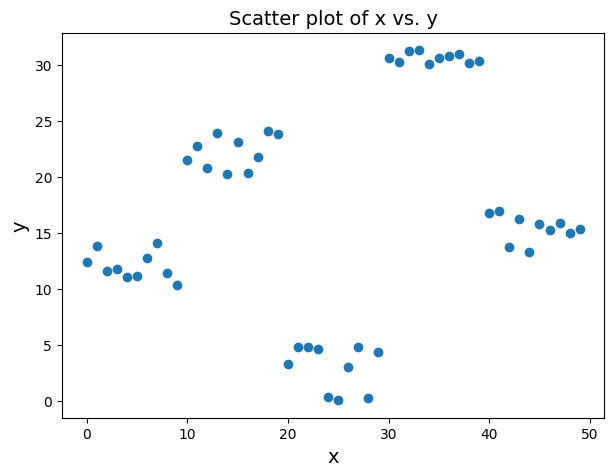

In [6]:
plt.figure(figsize=(7,5))
plt.plot(x, y, "o")
plt.title("Scatter plot of x vs. y", size=14)
plt.xlabel("x", size=14)
plt.ylabel("y", size=14)

plt.show()

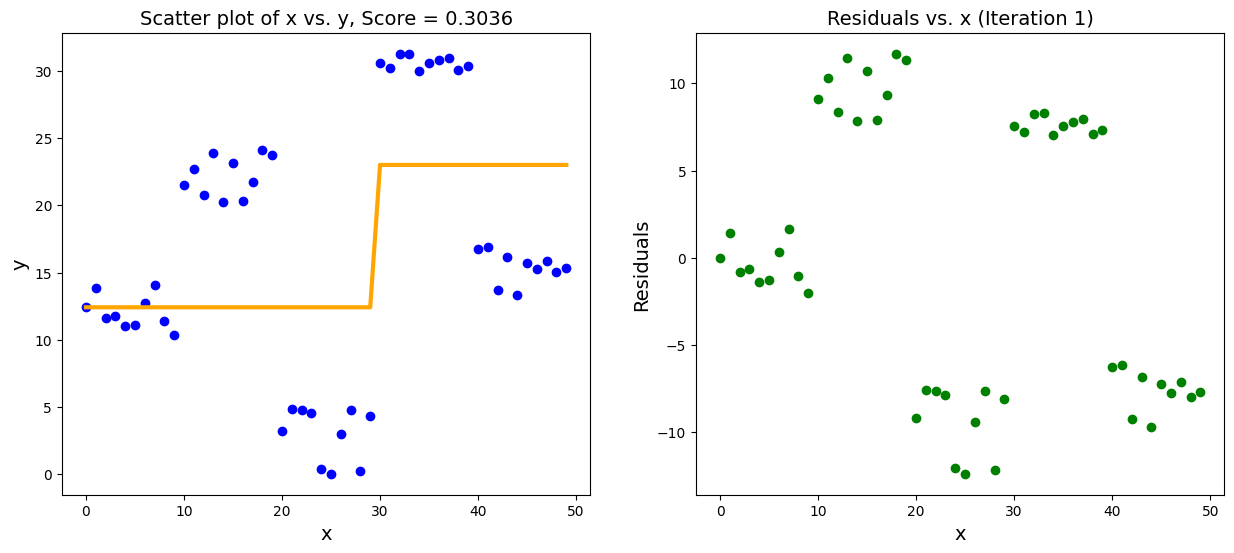

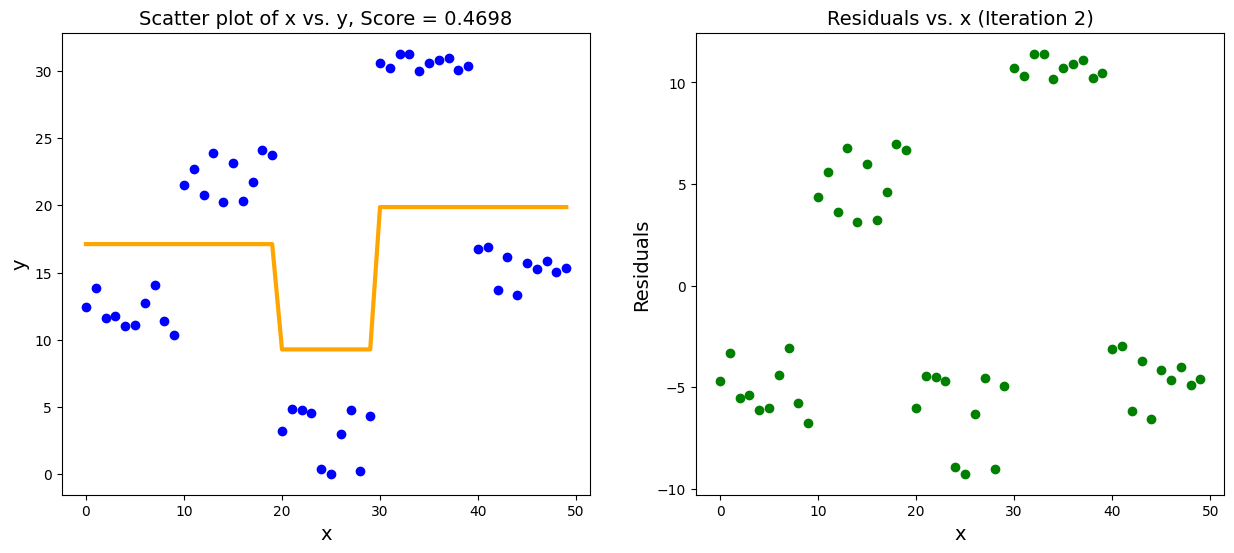

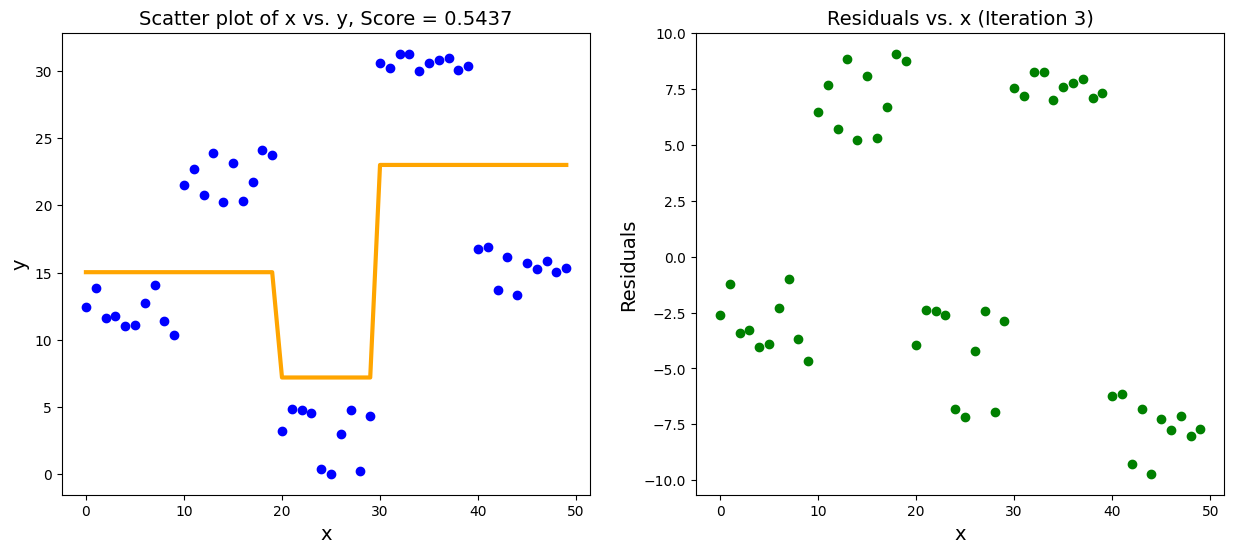

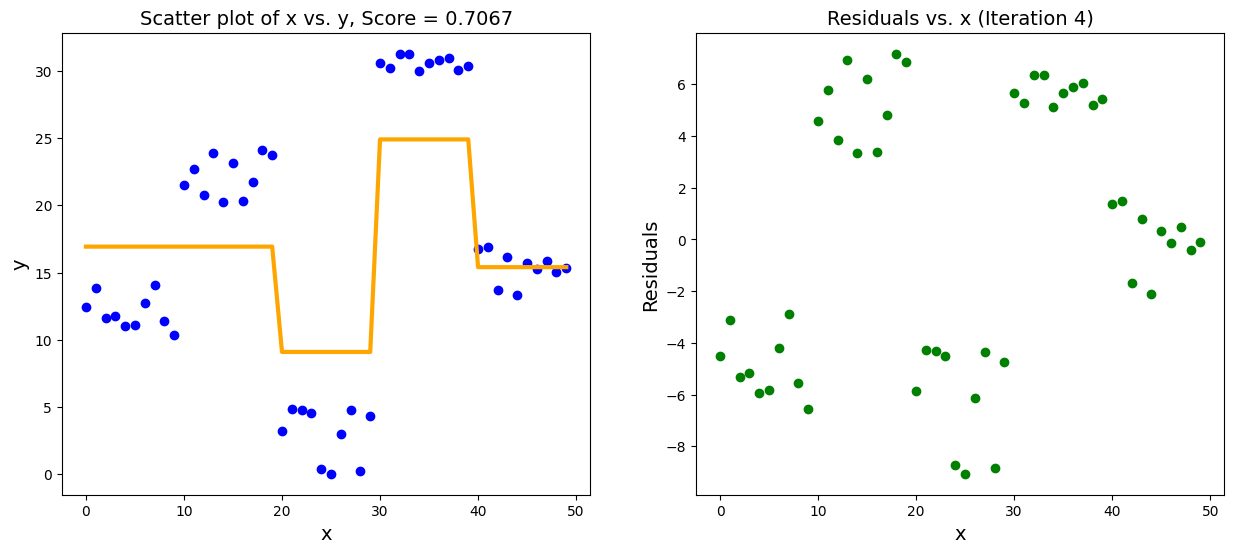

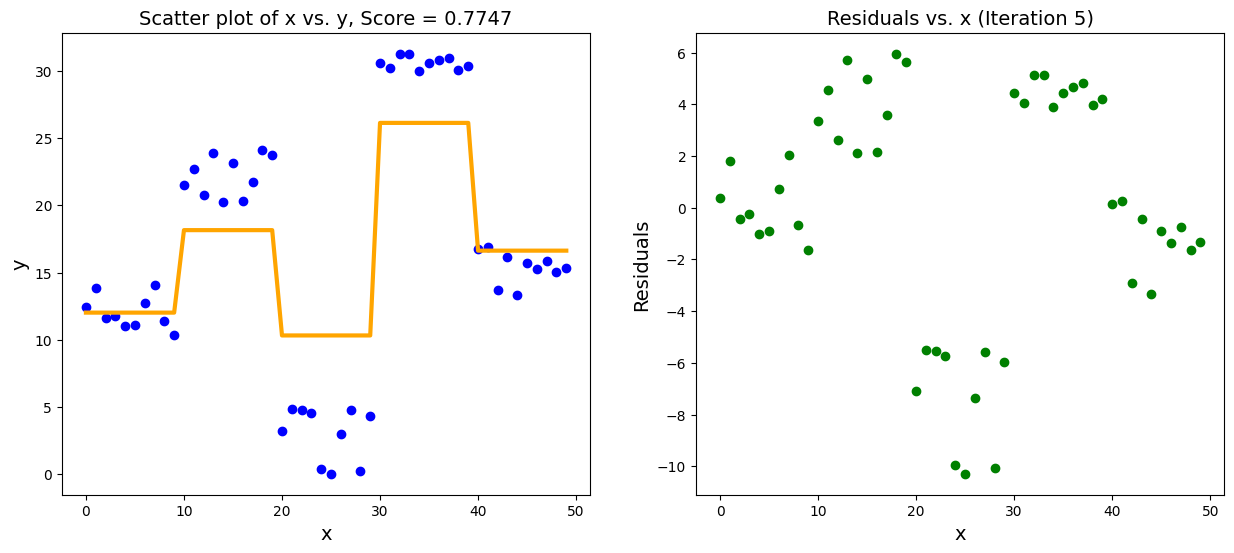

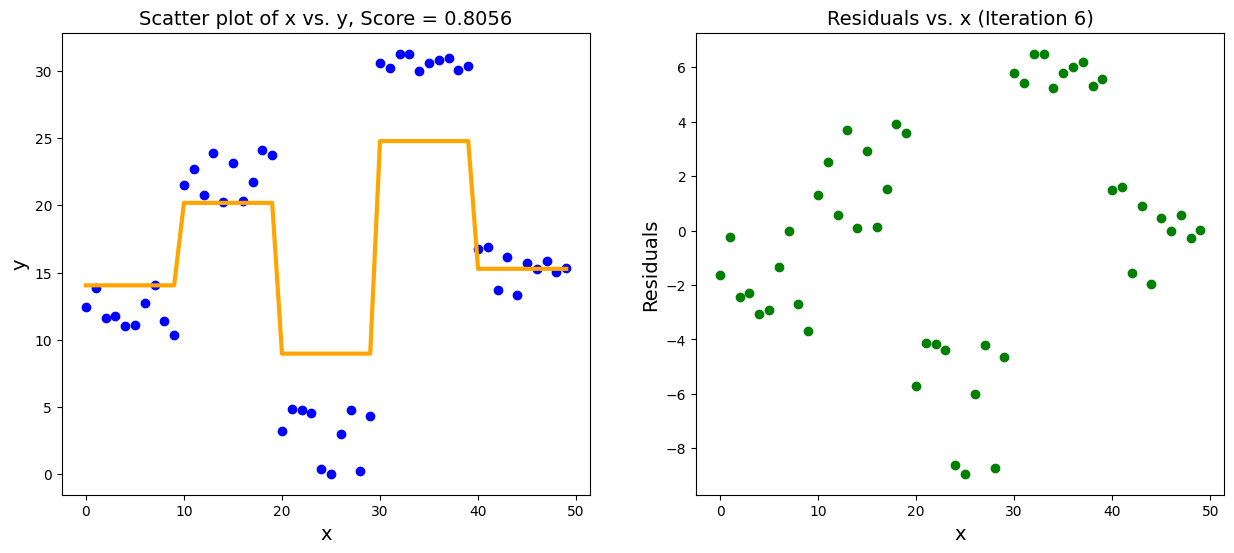

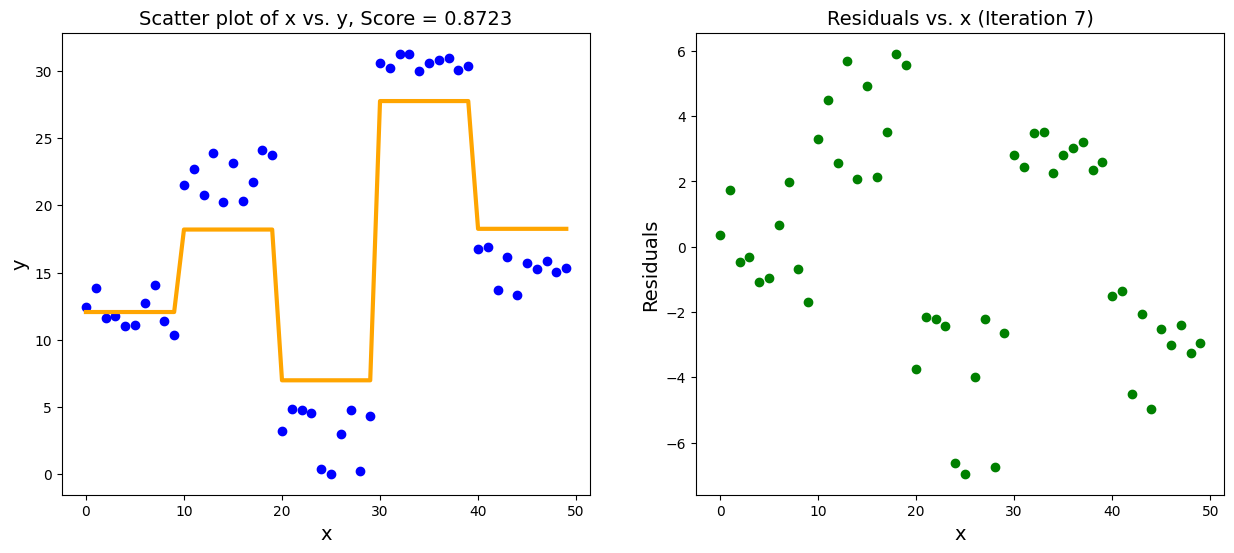

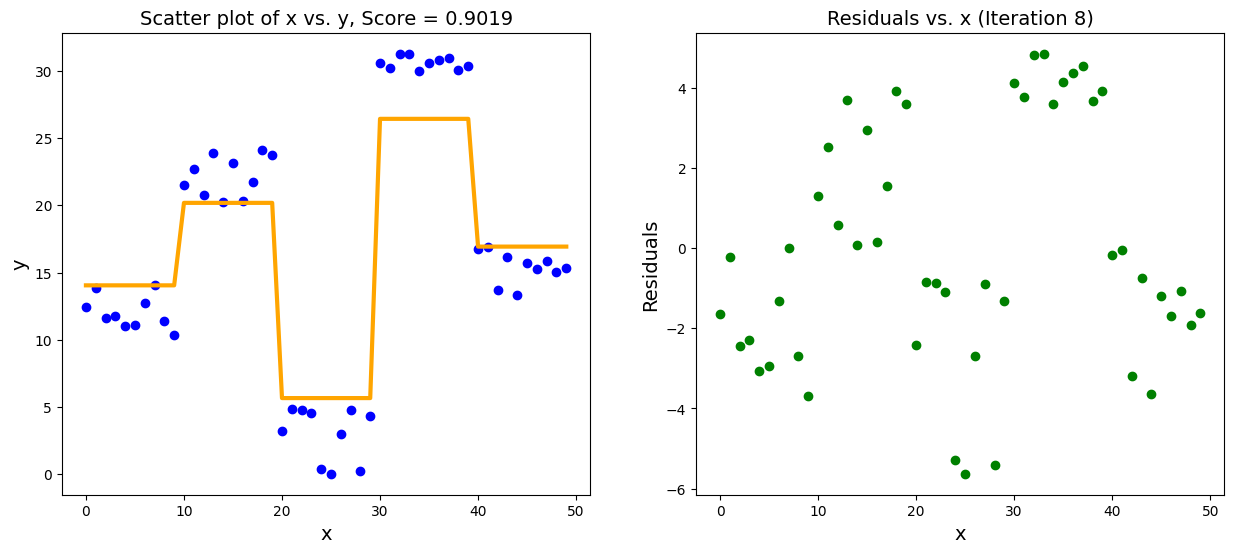

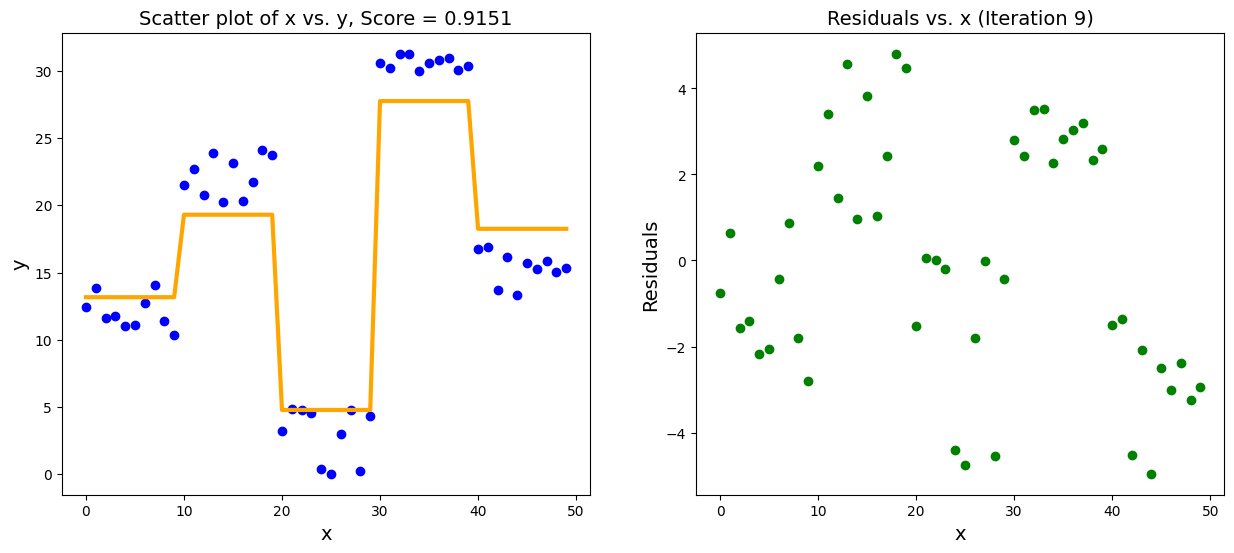

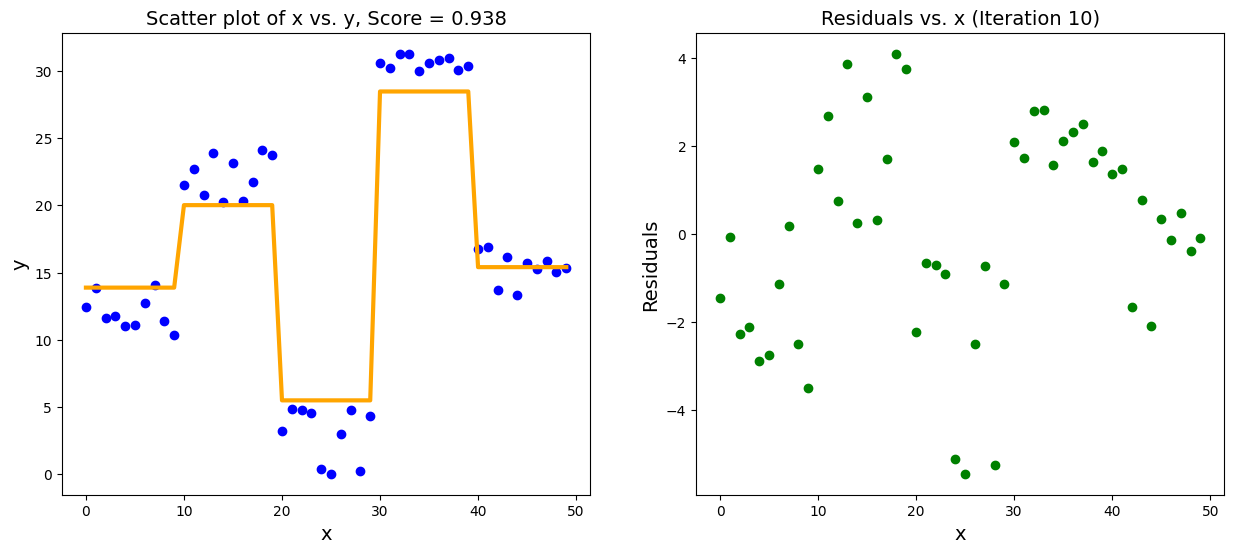

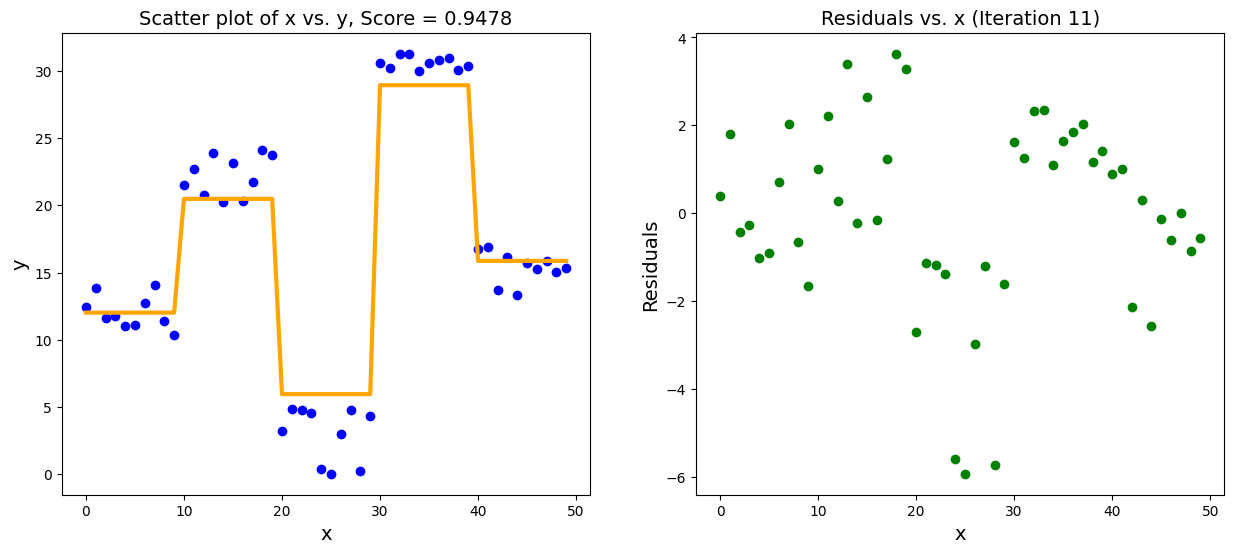

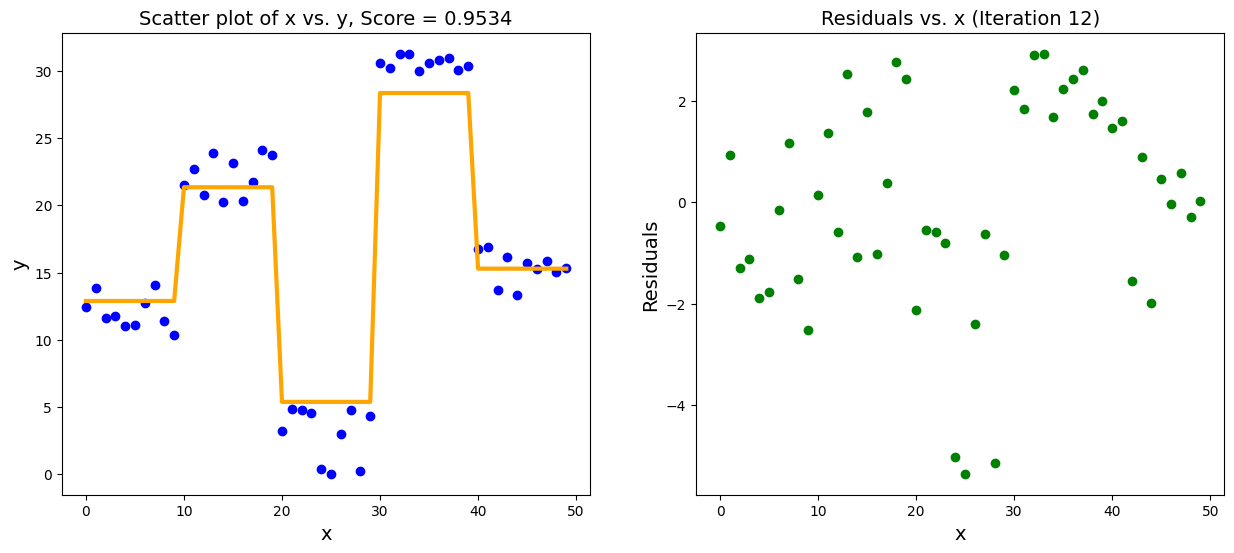

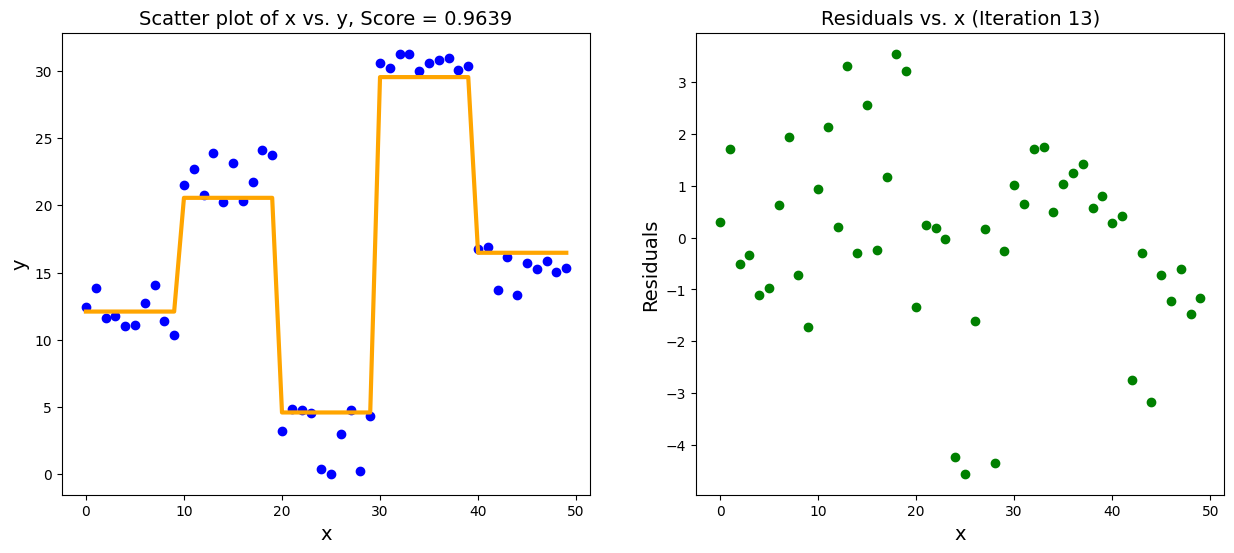

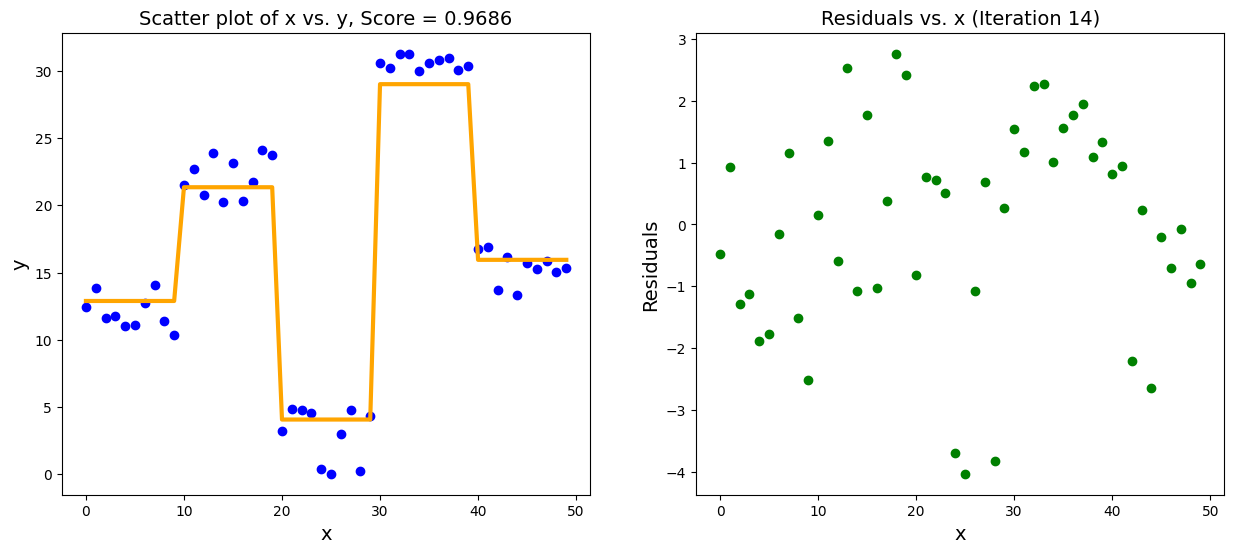

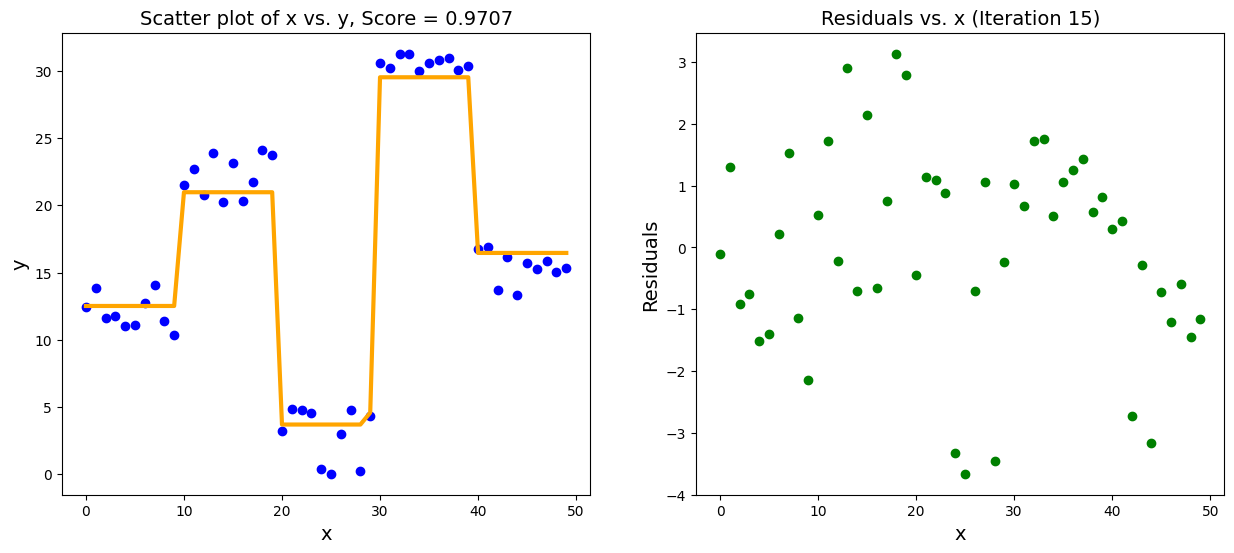

In [7]:
trees = []
y_ = y.copy()

for i in range(15):

    tree = DecisionTreeRegressor(max_depth=1, random_state=27) #базовые алгоритмы
    tree.fit(x, y_)

    trees.append(tree)
    y_pred = 0

    for tree in trees:
        y_pred += tree.predict(x).reshape((50, 1))

    # общее отклонение от таргета на данной итерации предсказаний
    residuals = y - y_pred

    # на следующей итерации будем предсказывать лишь остатки от предсказания предыдущих остатков и т.д.
    y_ = y_ - tree.predict(x).reshape((50, 1))
    
    score = r2_score(
        y, y_pred
    )

    plt.figure(figsize=(15, 6))
    plt.subplot(121)
    plt.plot(x, y, "o", color="blue")
    plt.plot(x, y_pred, color="orange", linewidth=3)
    plt.title(f"Scatter plot of x vs. y, Score = {round(score, 4)}", size=14)
    plt.xlabel("x", size=14)
    plt.ylabel("y", size=14)

    plt.subplot(122)
    plt.plot(x, residuals, "o", color="green")
    plt.title(f"Residuals vs. x (Iteration {i+1})", size=14)
    plt.ylabel("Residuals", size=14)
    plt.xlabel("x", size=14)
    plt.show()

## А как работает бэггинг?

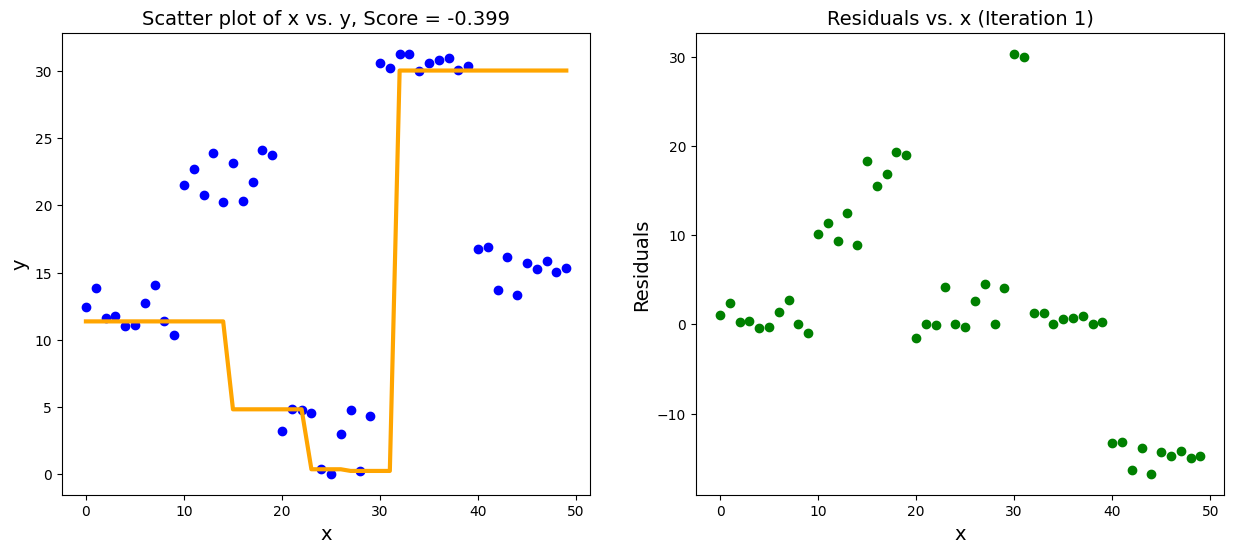

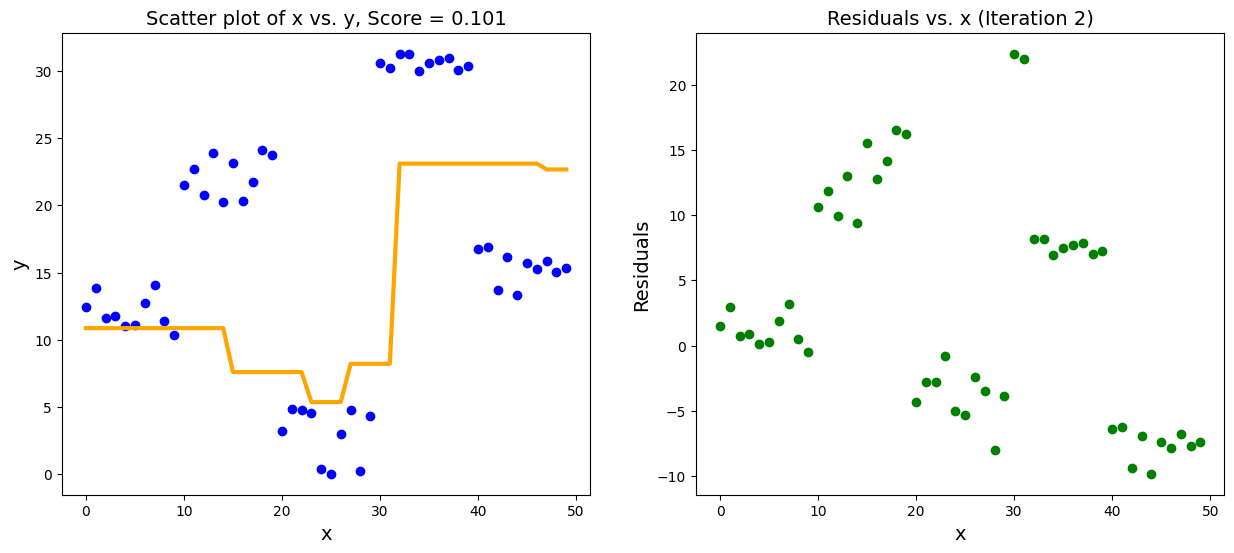

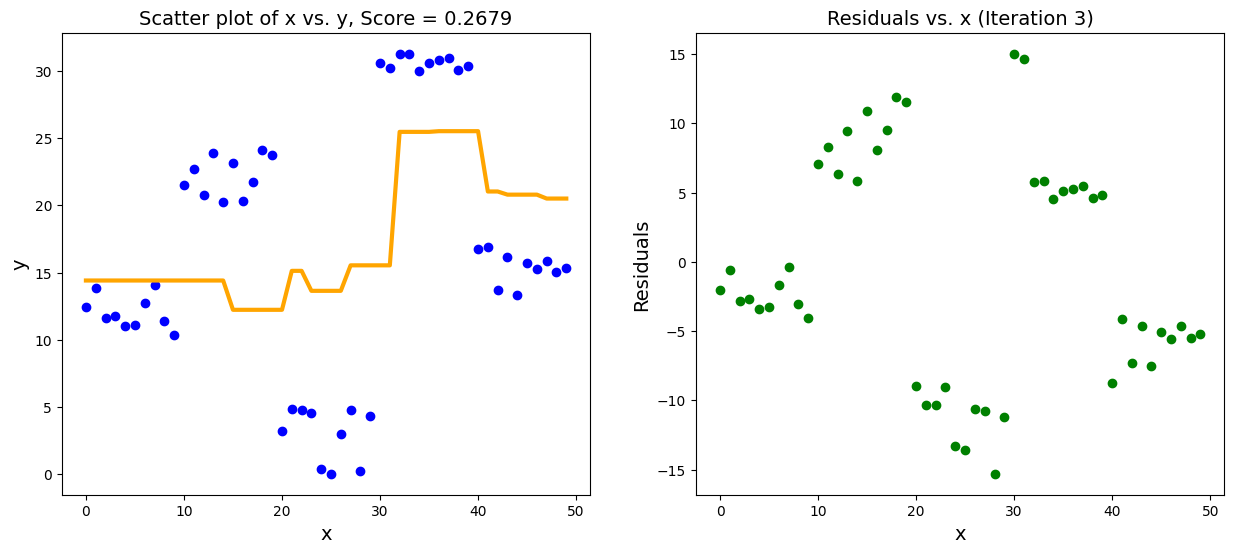

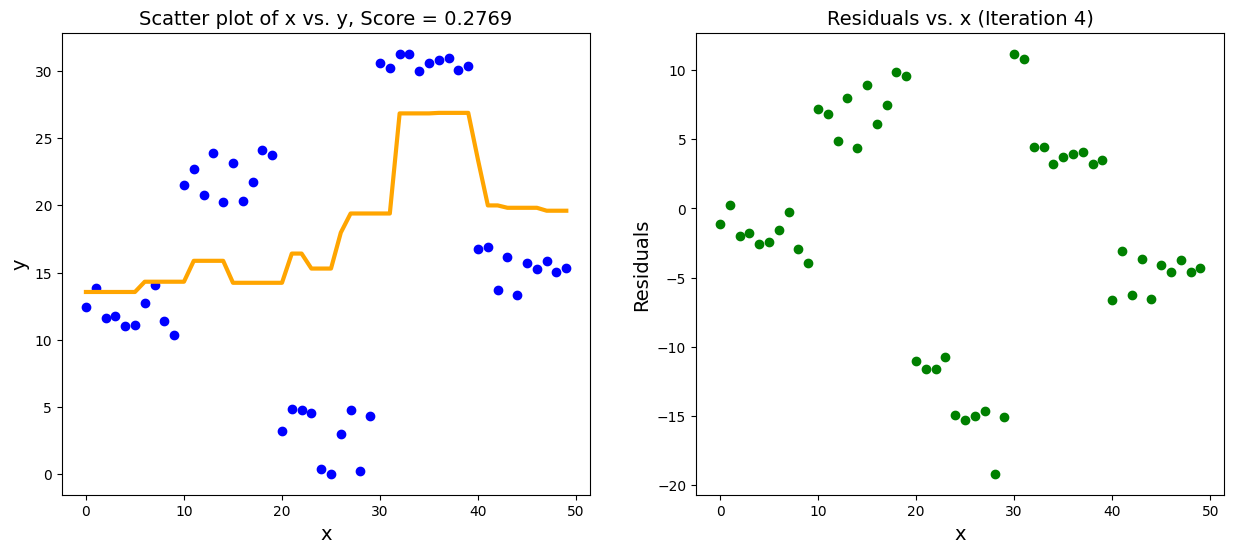

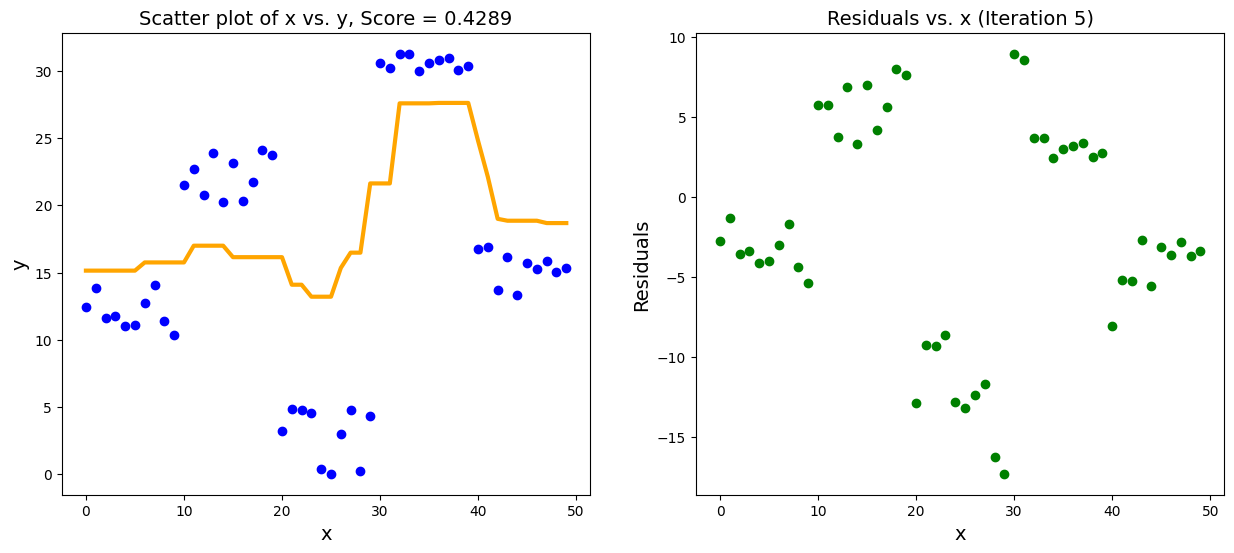

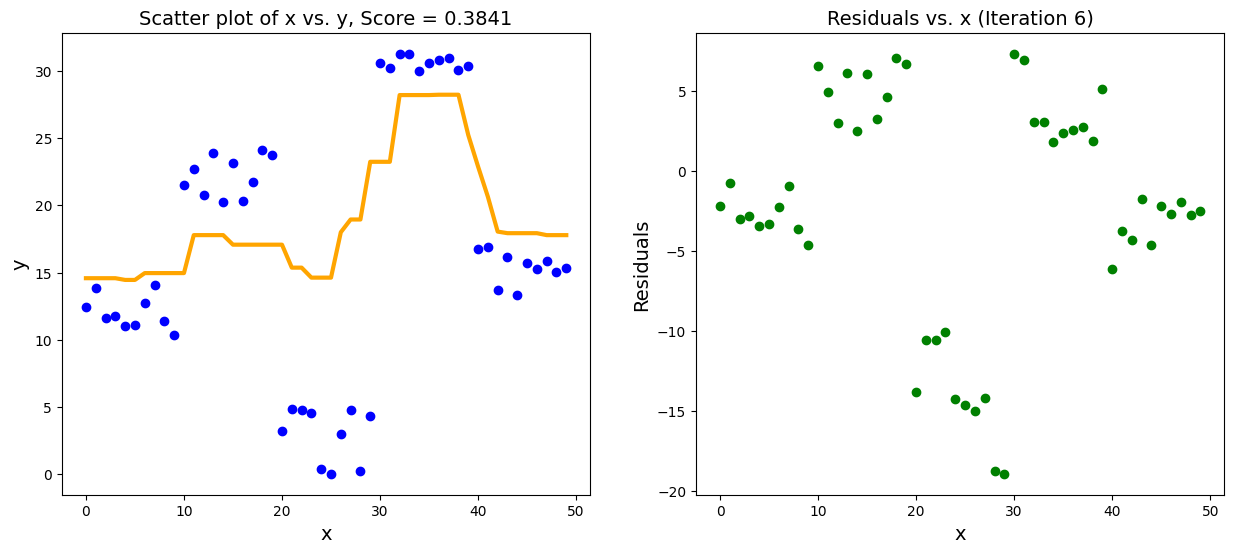

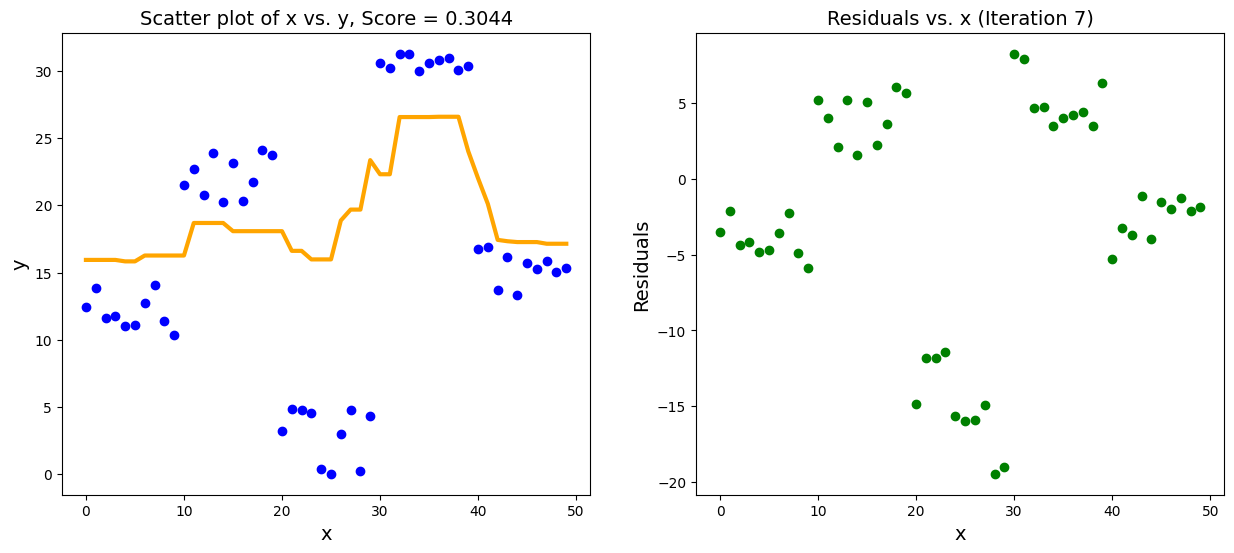

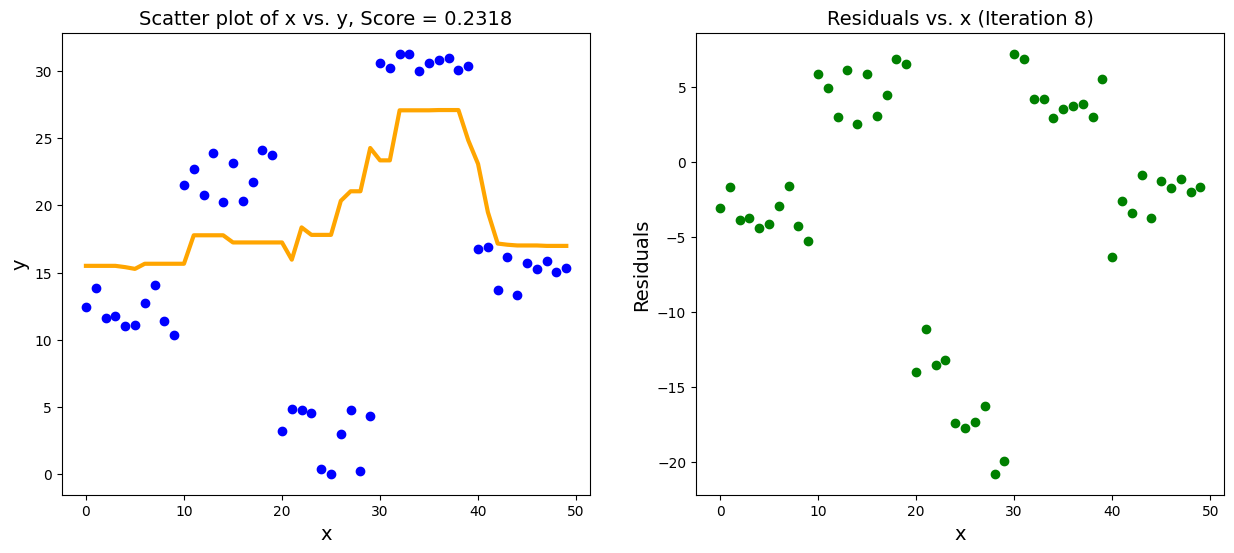

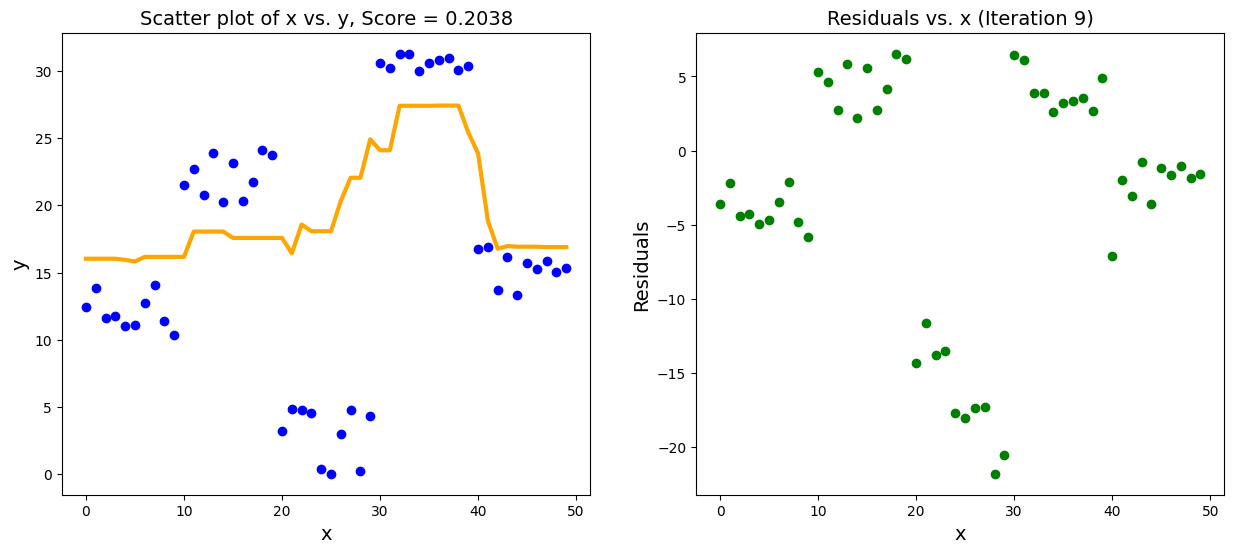

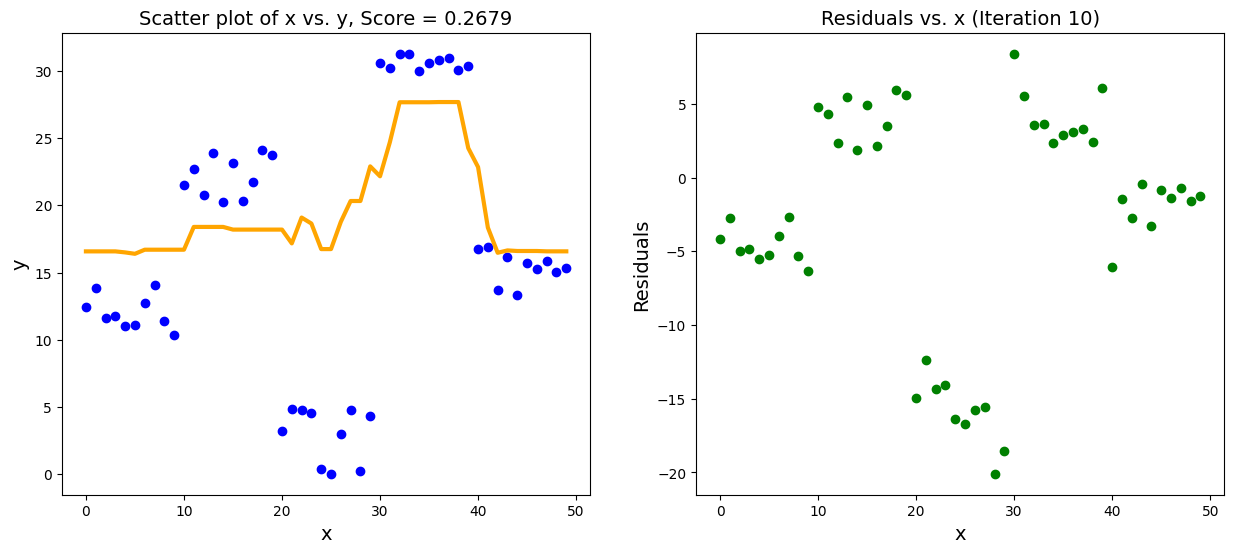

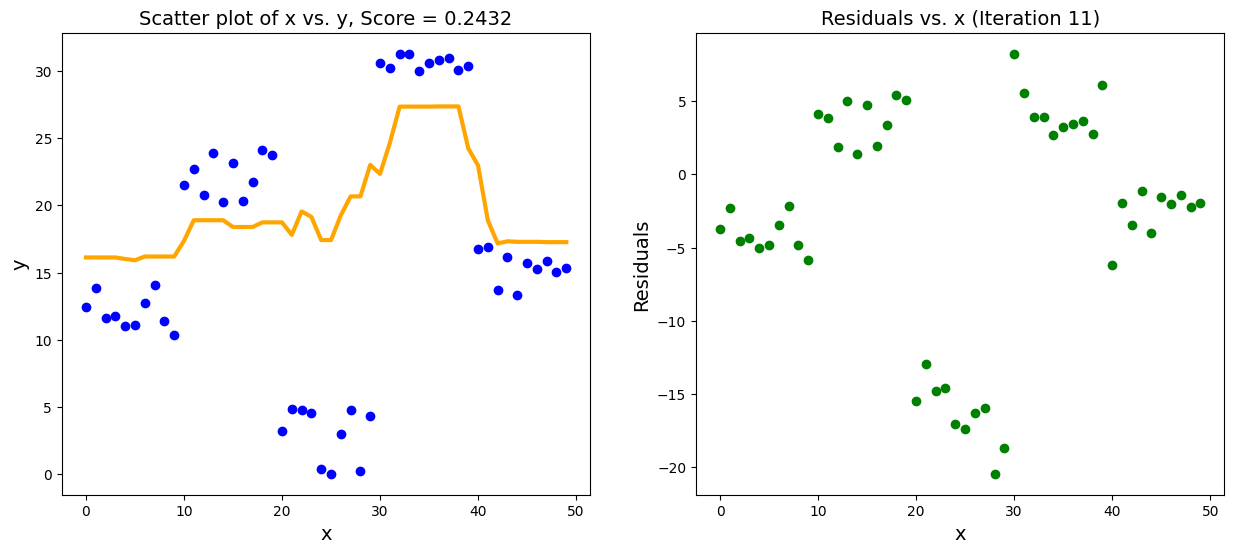

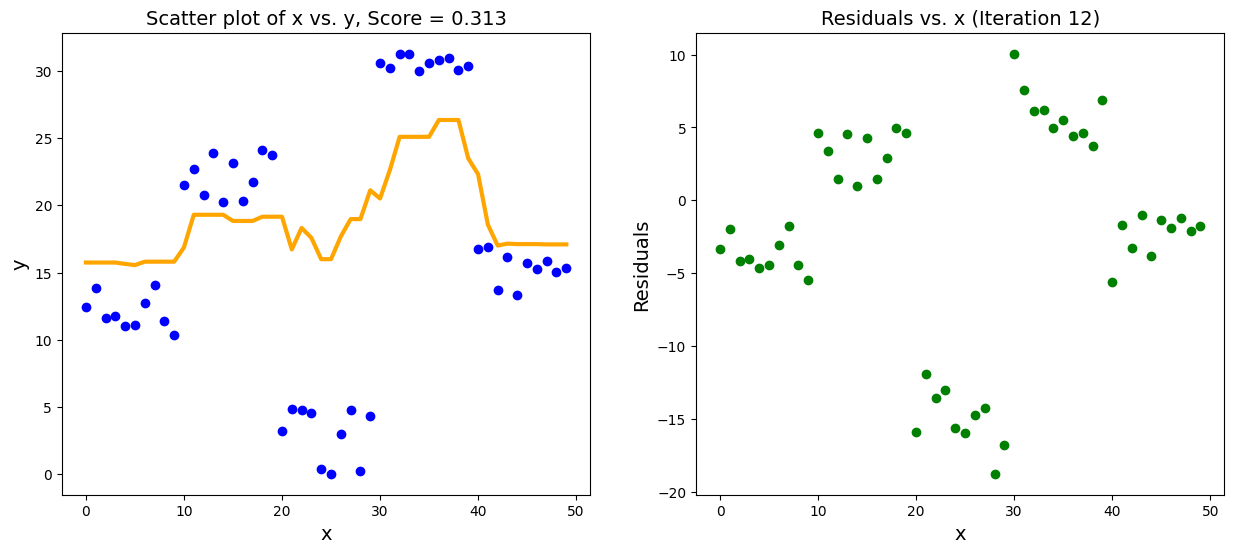

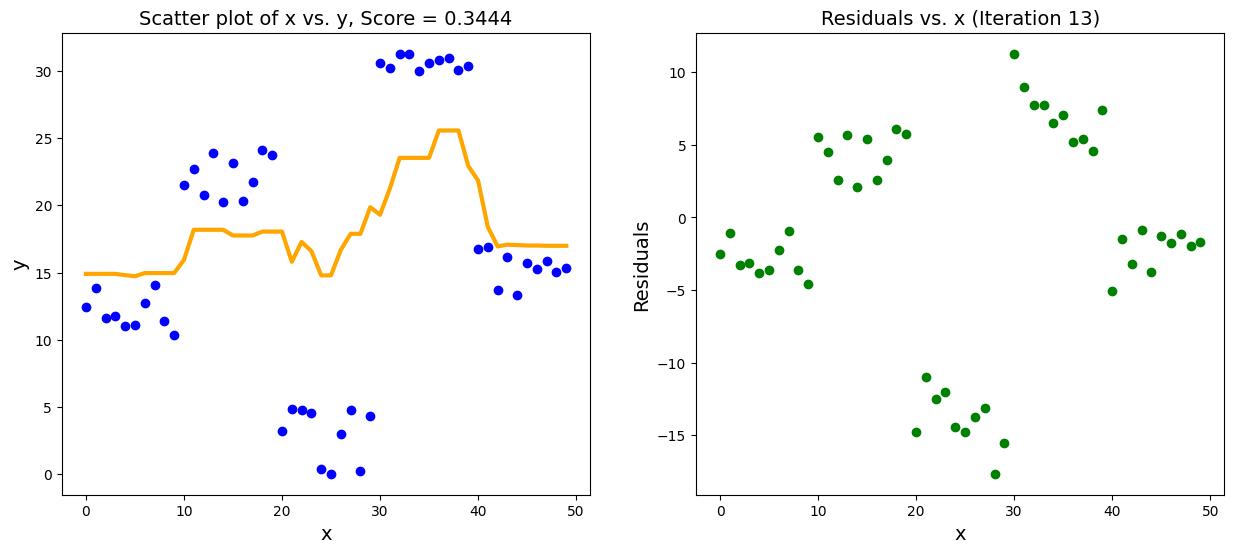

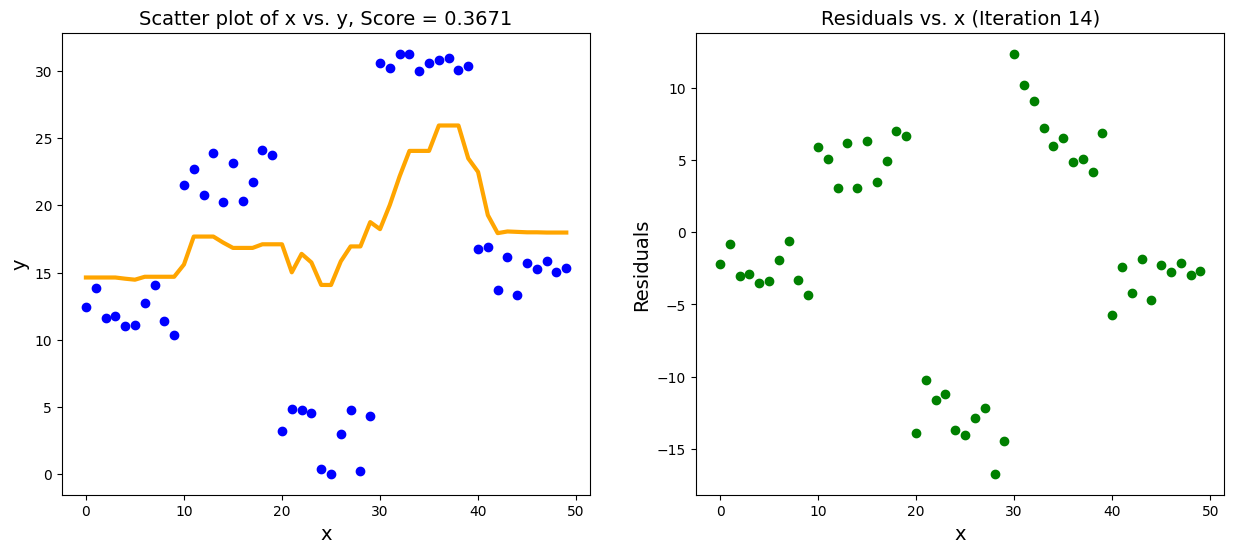

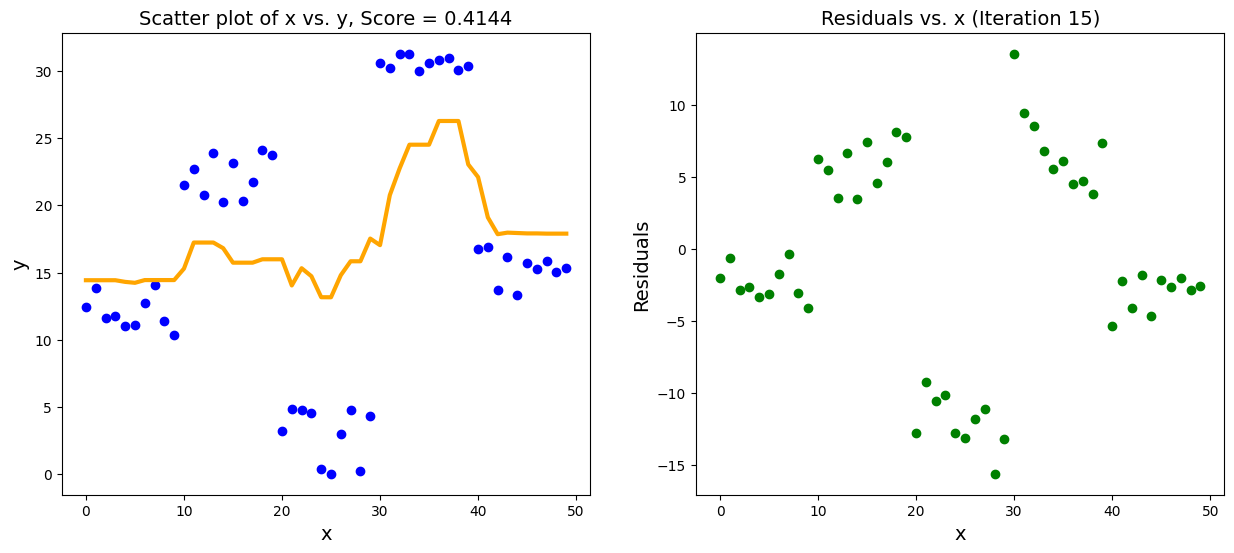

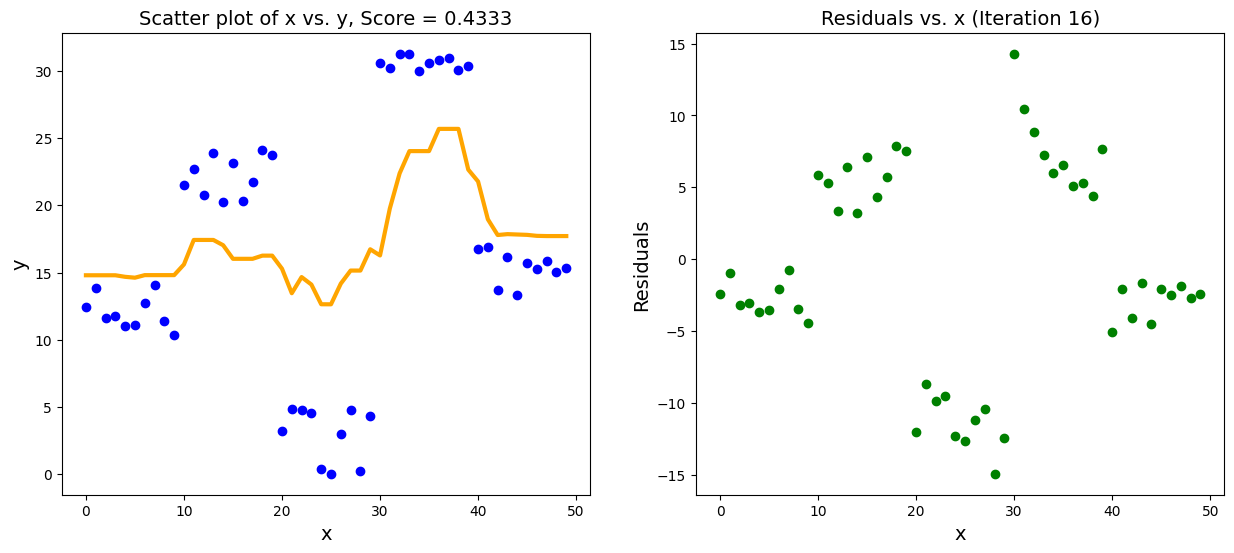

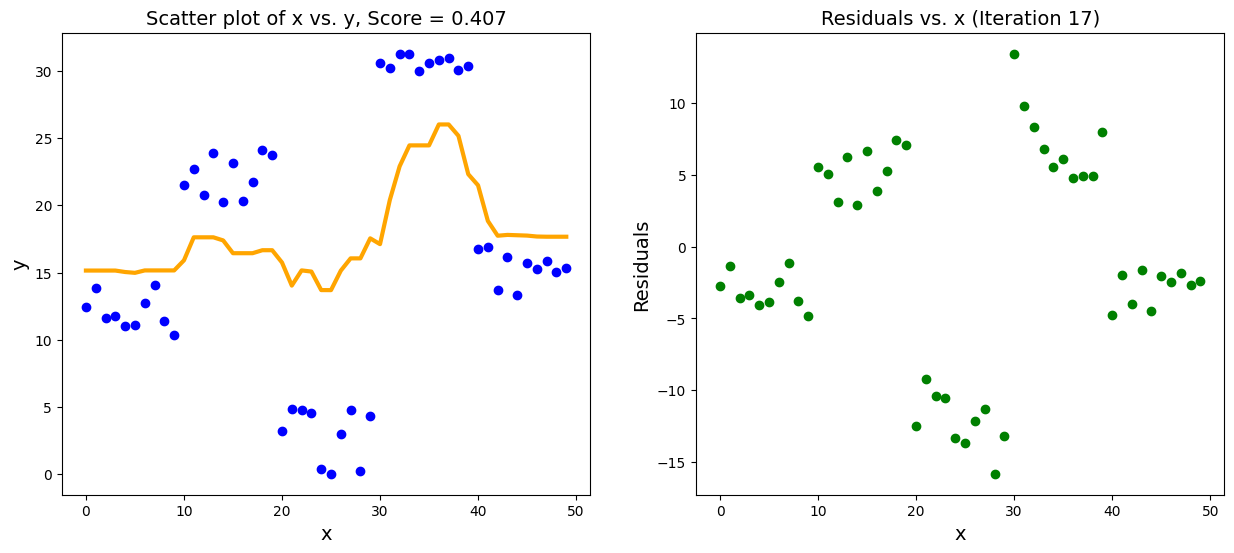

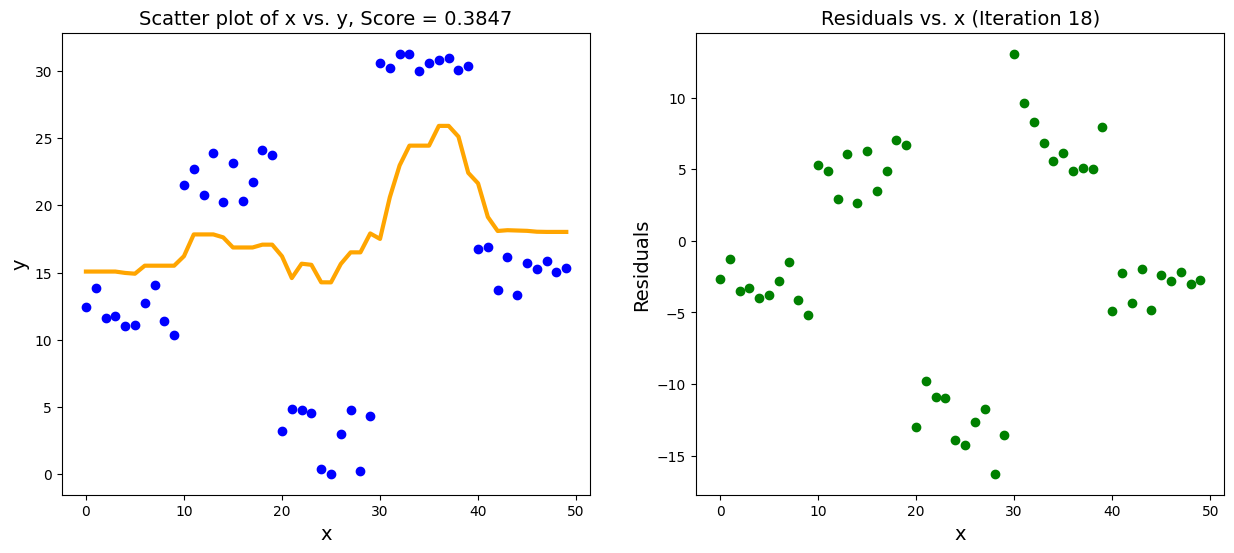

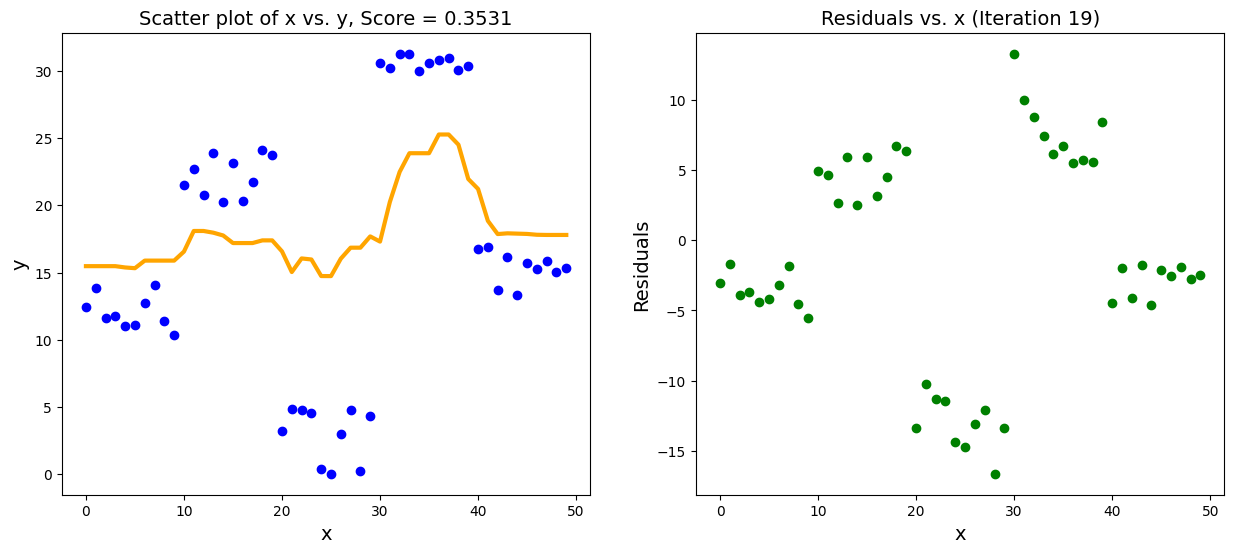

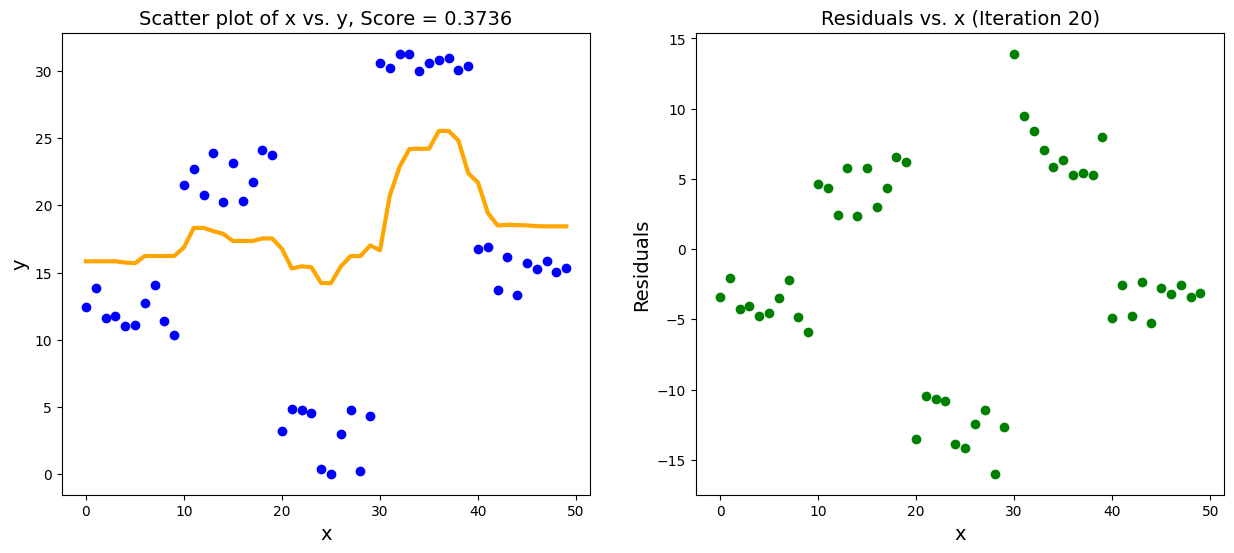

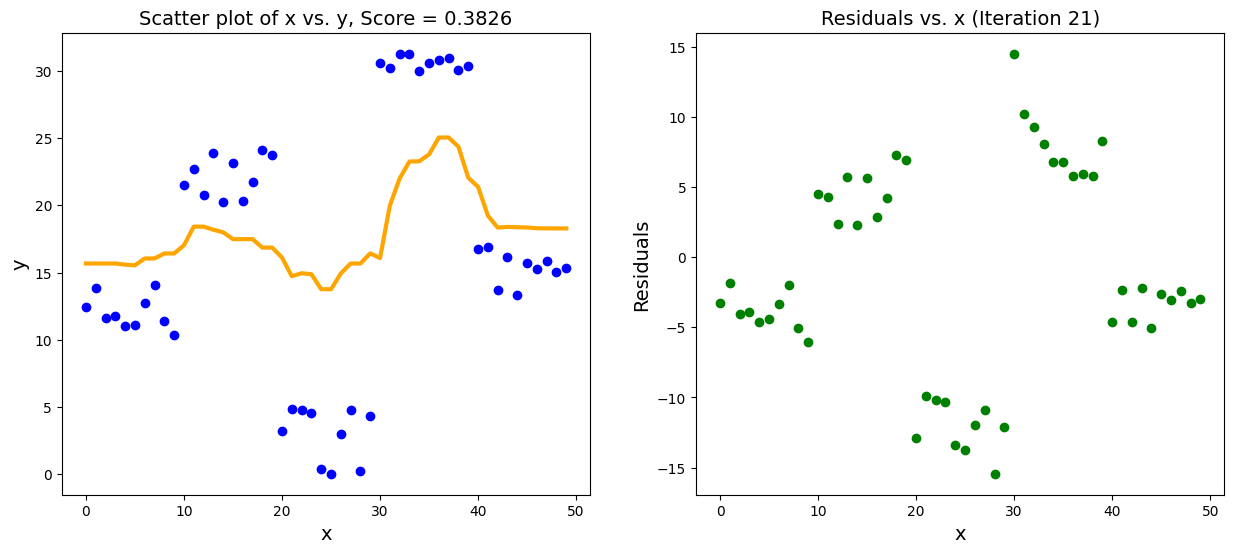

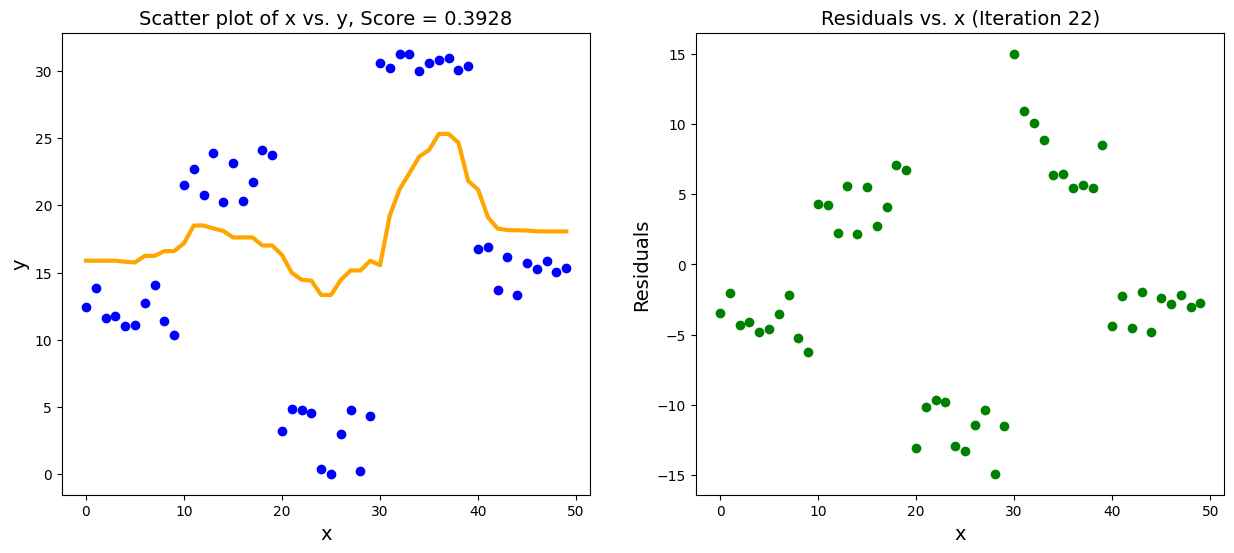

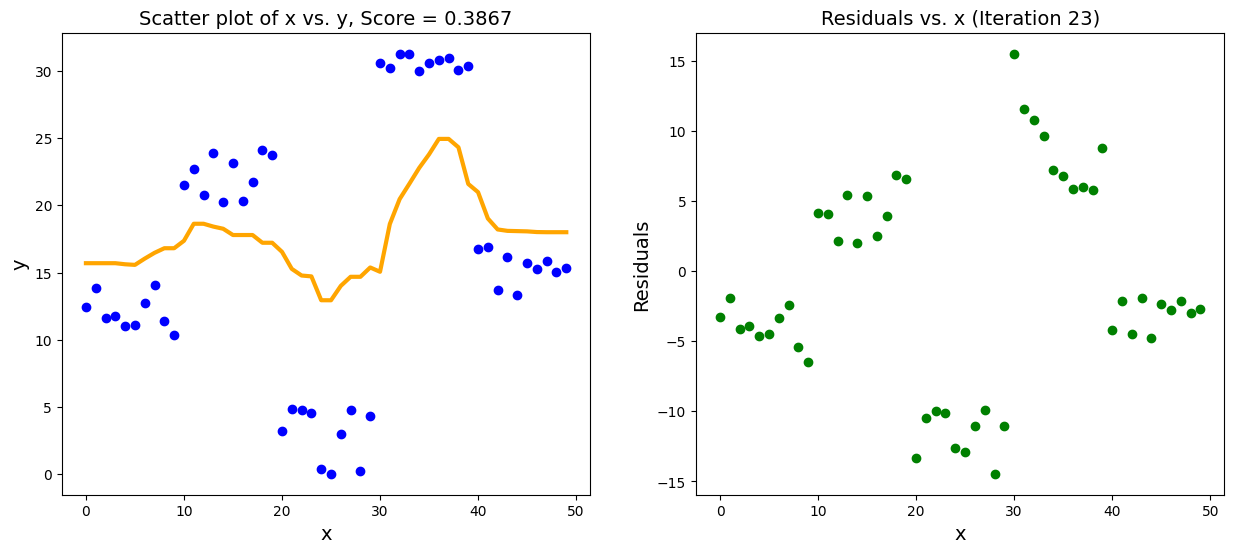

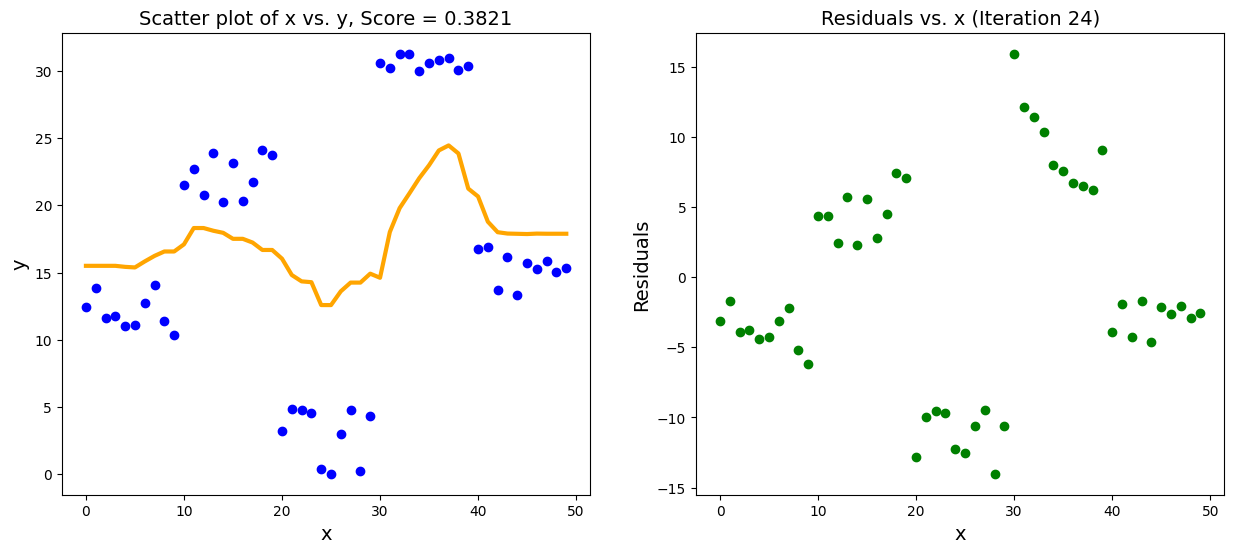

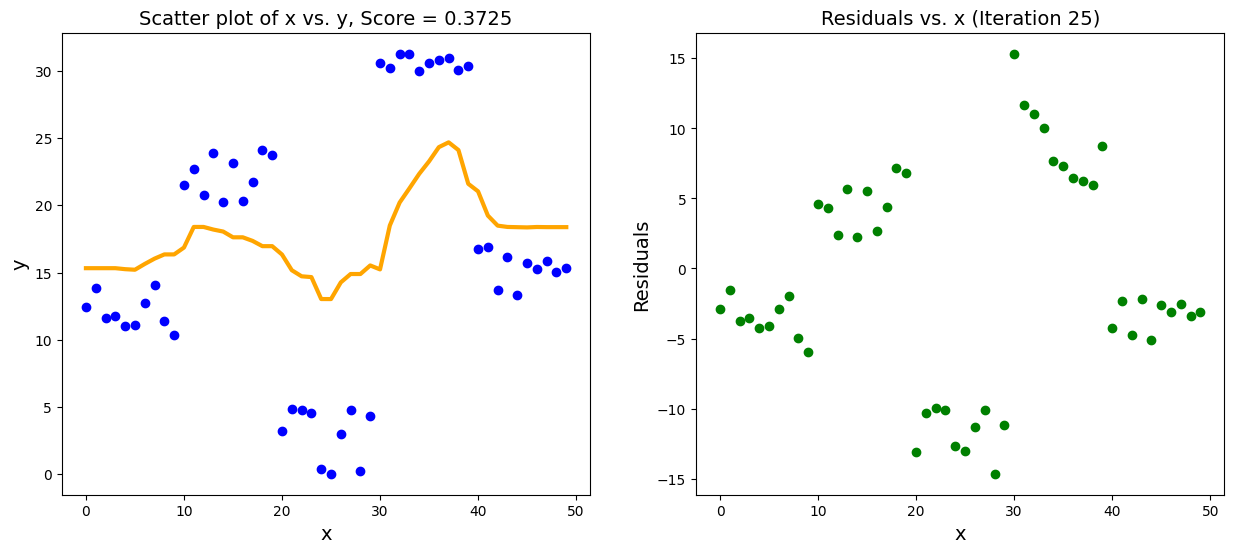

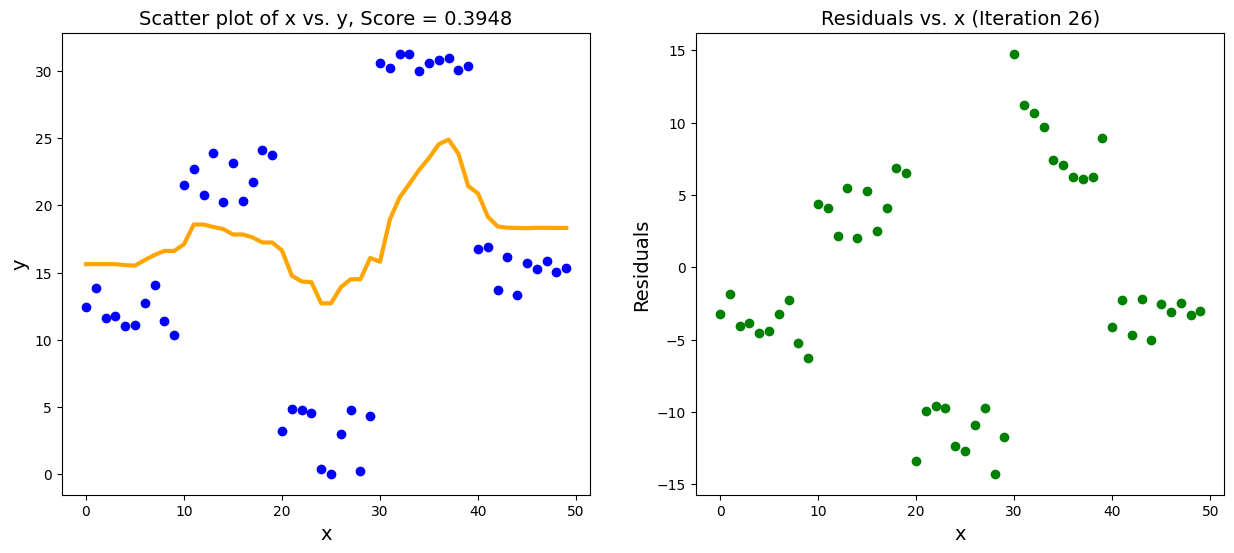

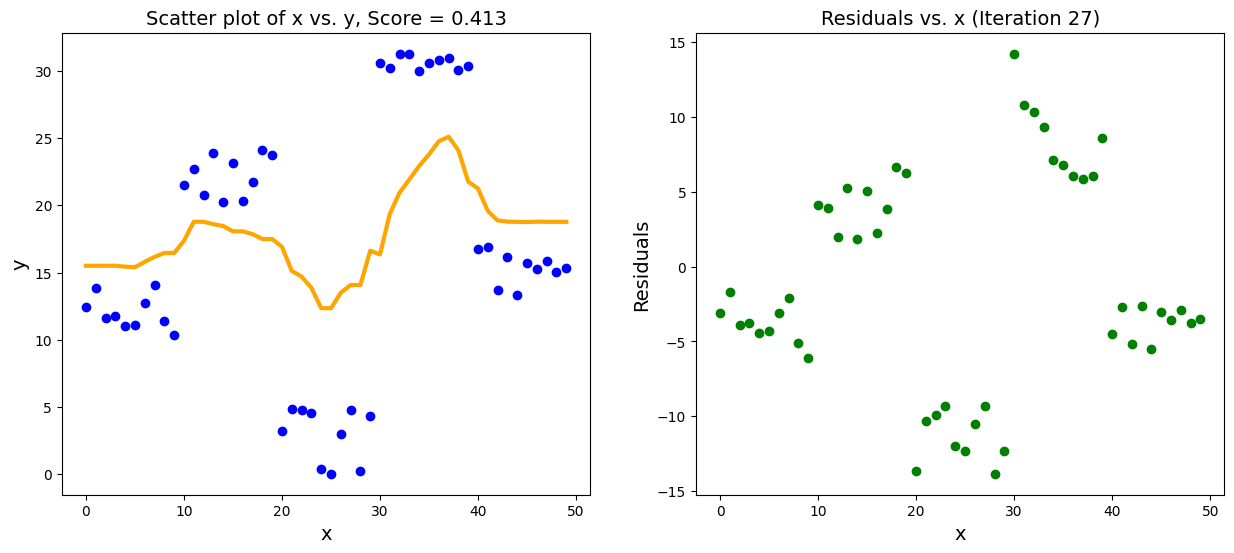

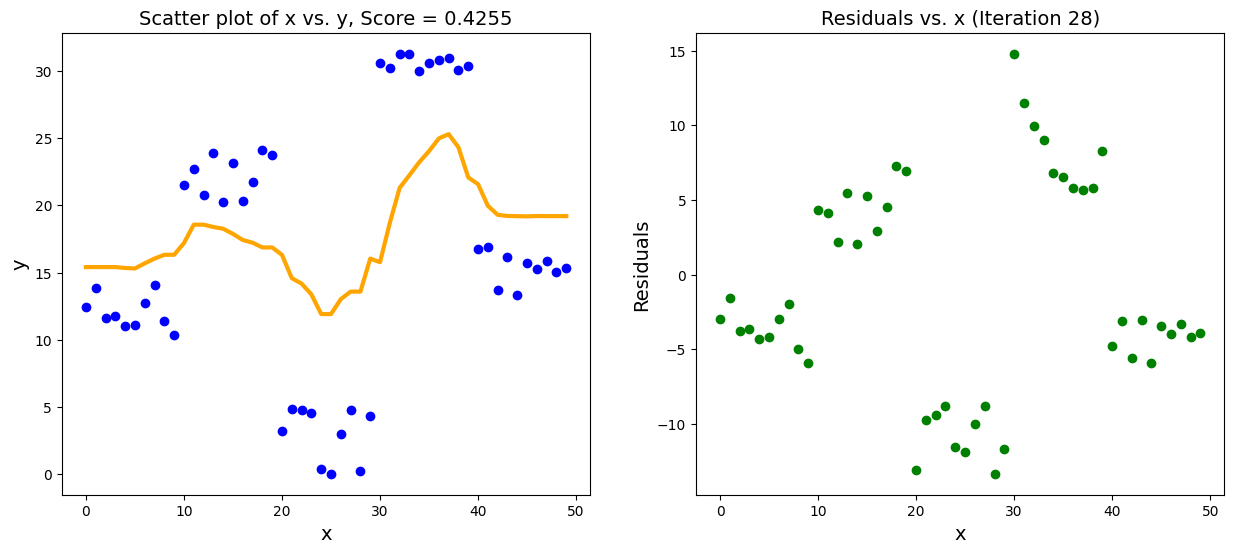

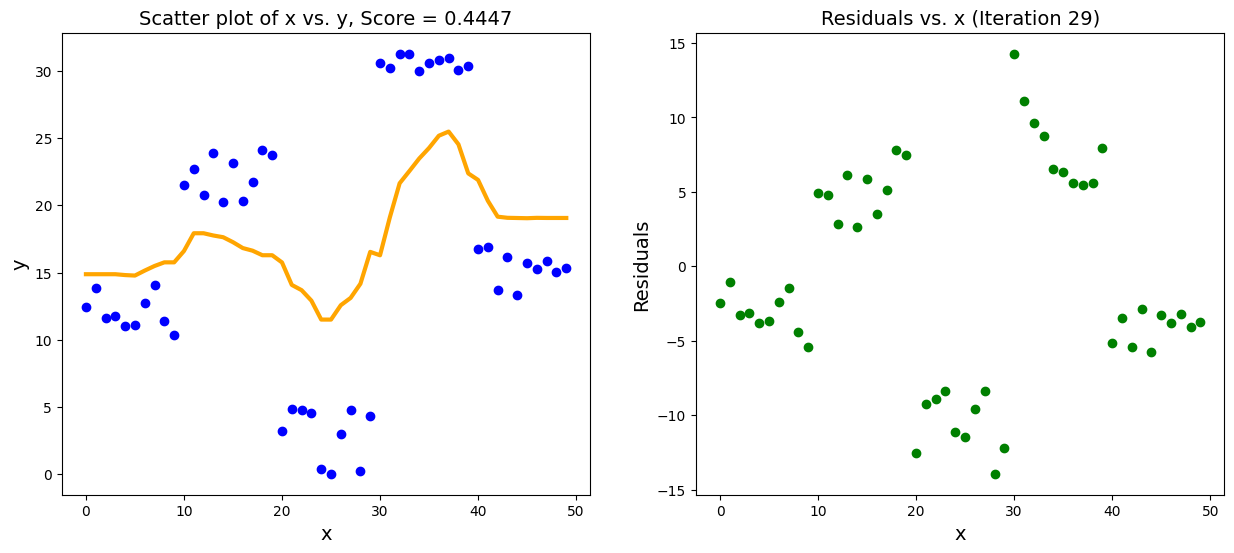

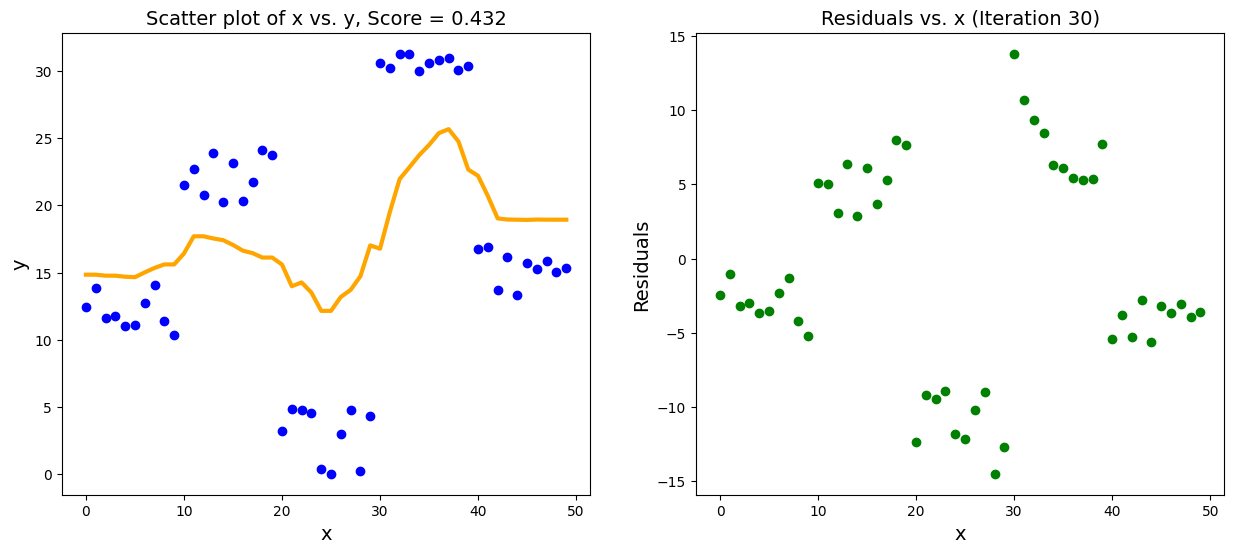

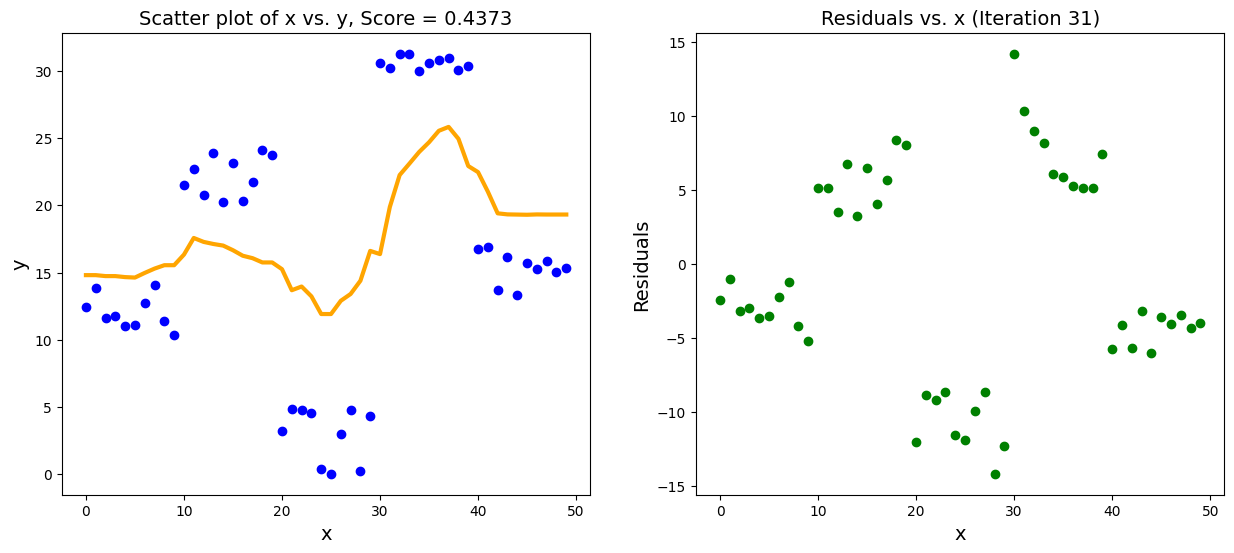

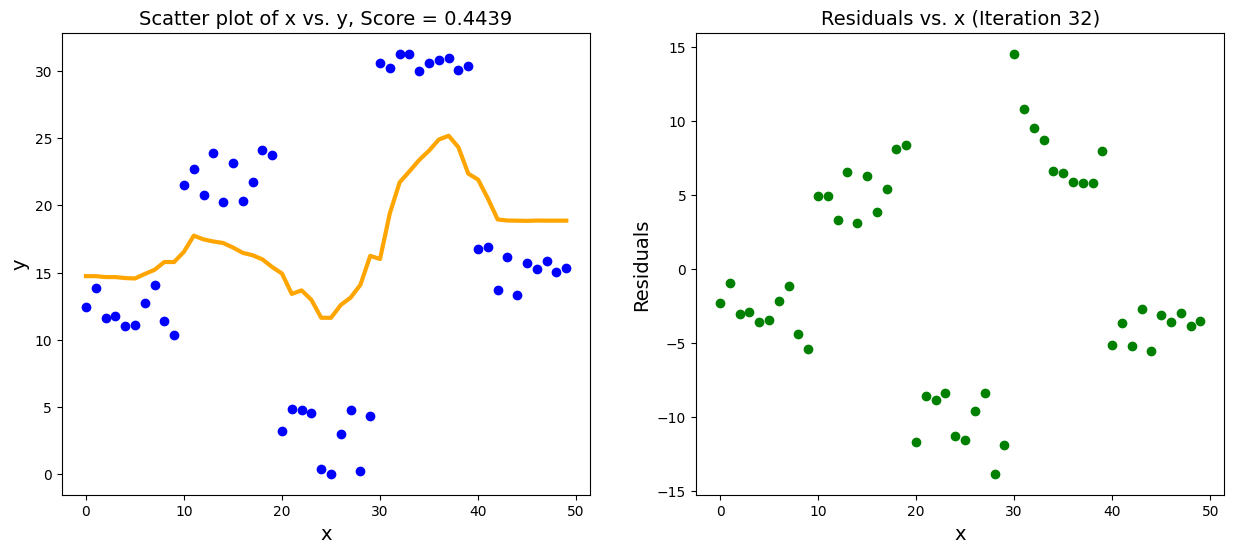

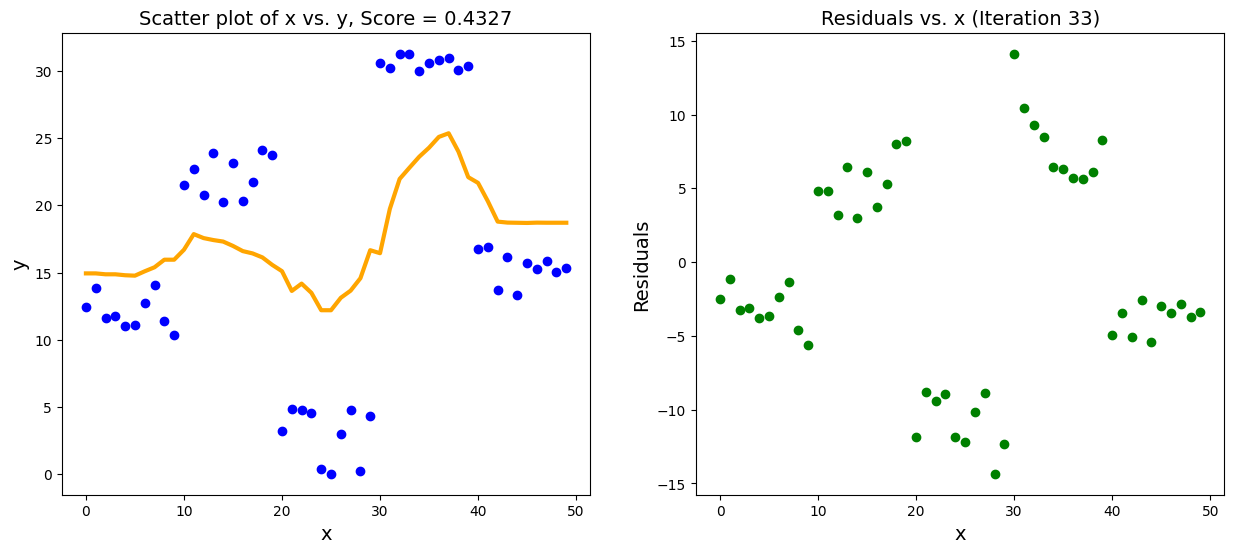

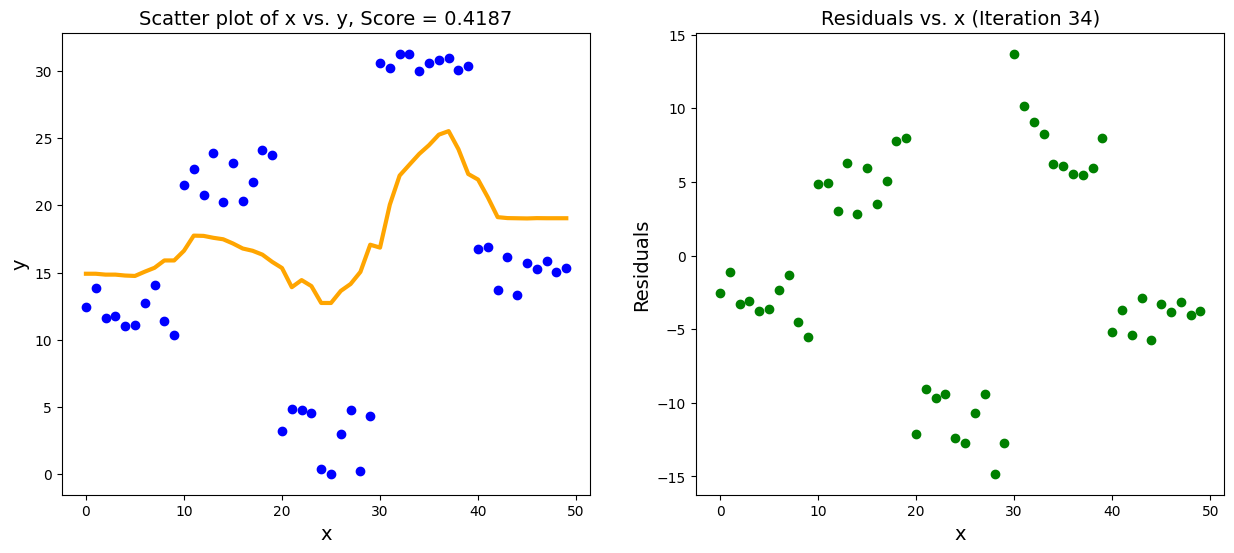

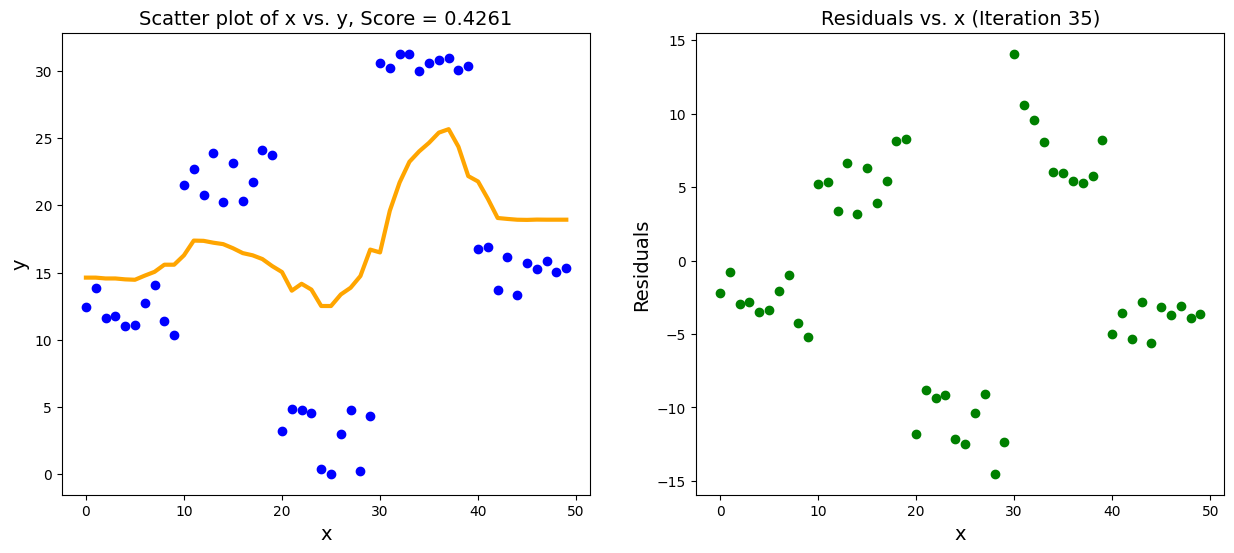

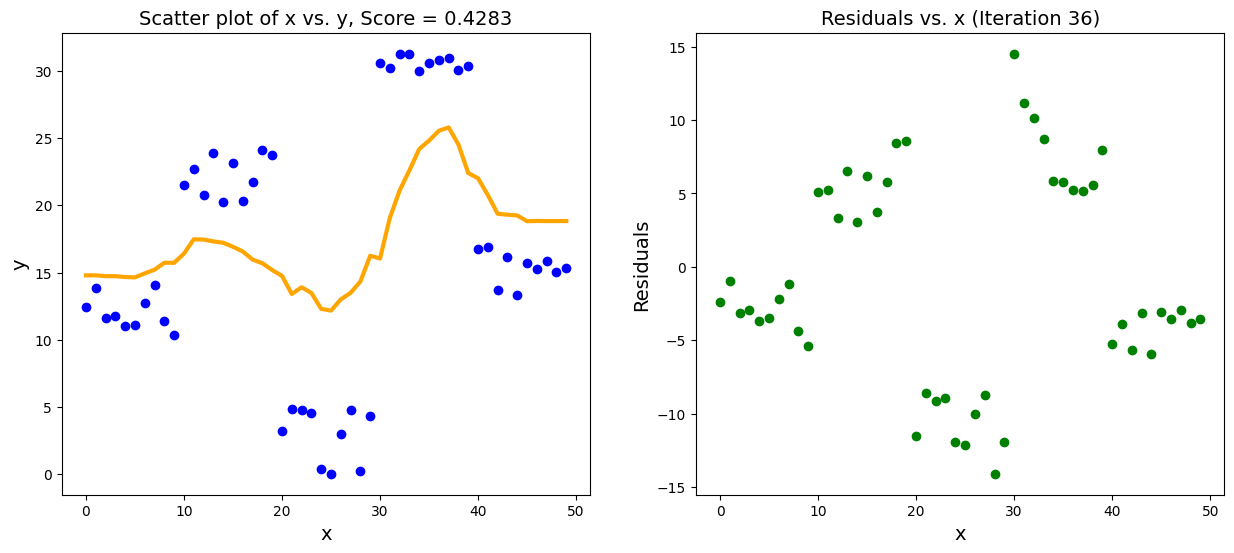

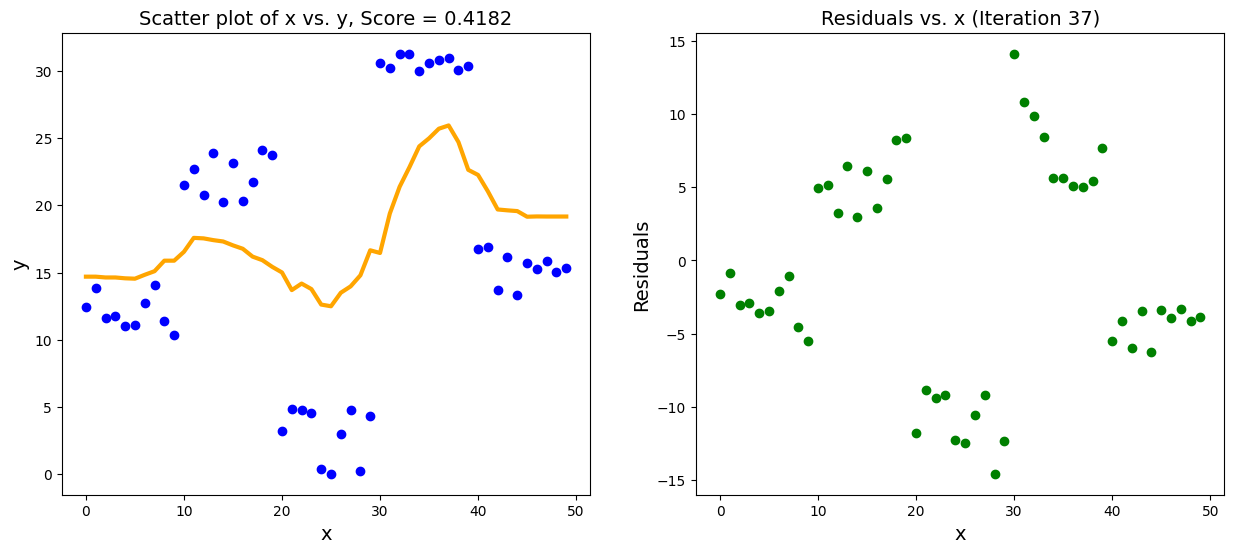

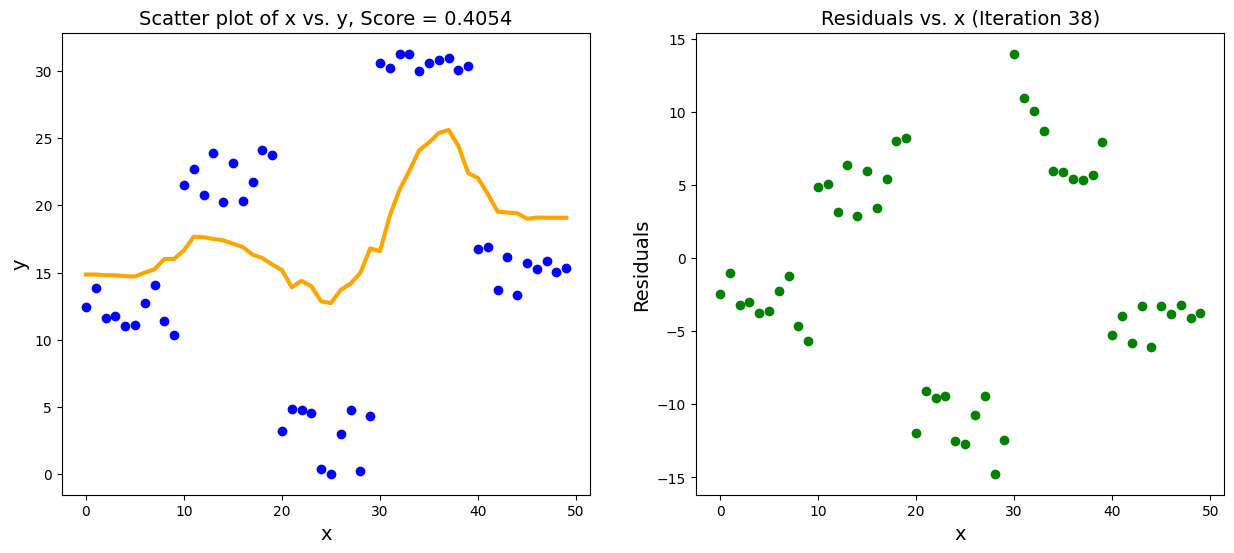

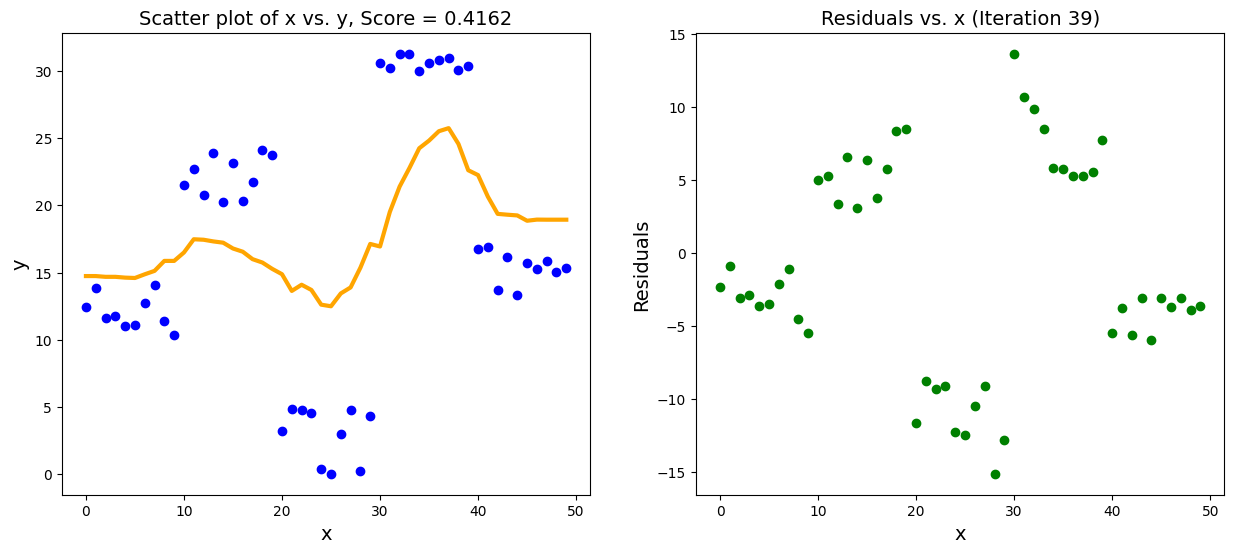

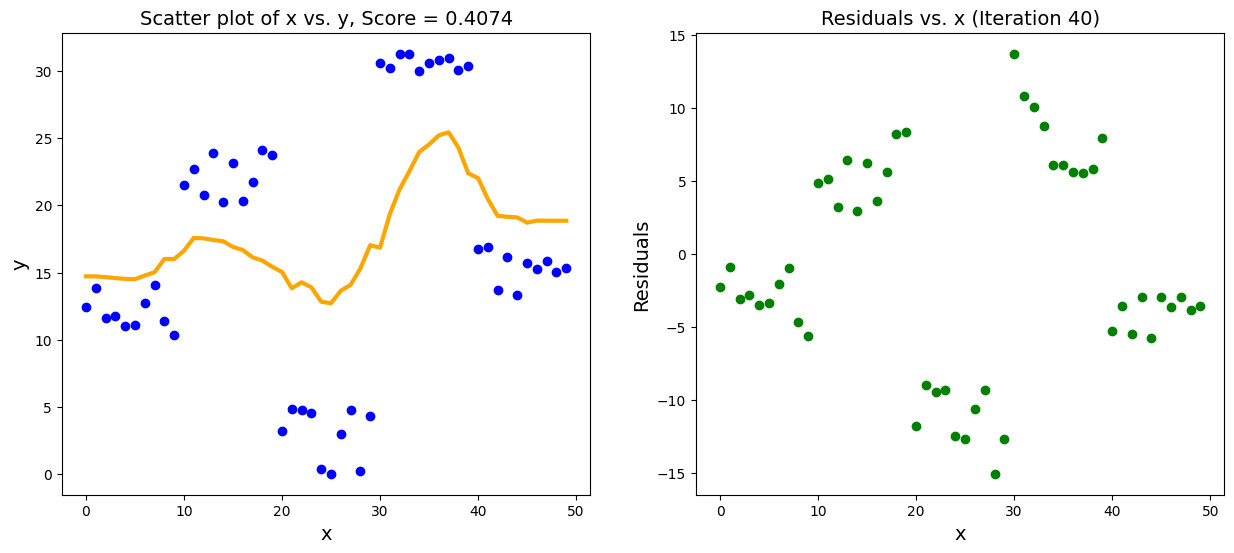

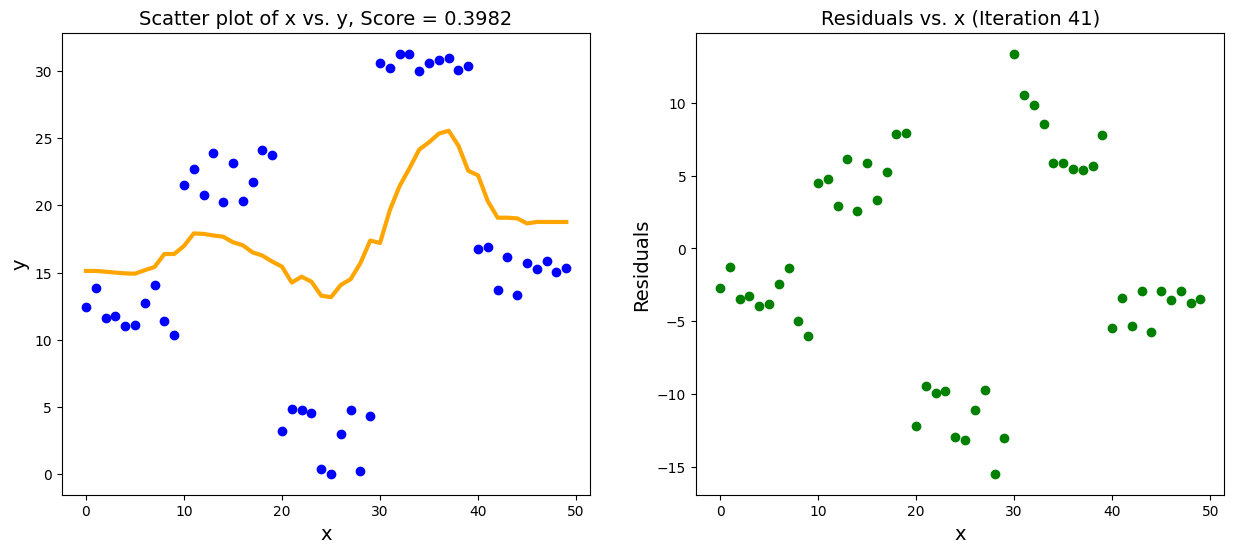

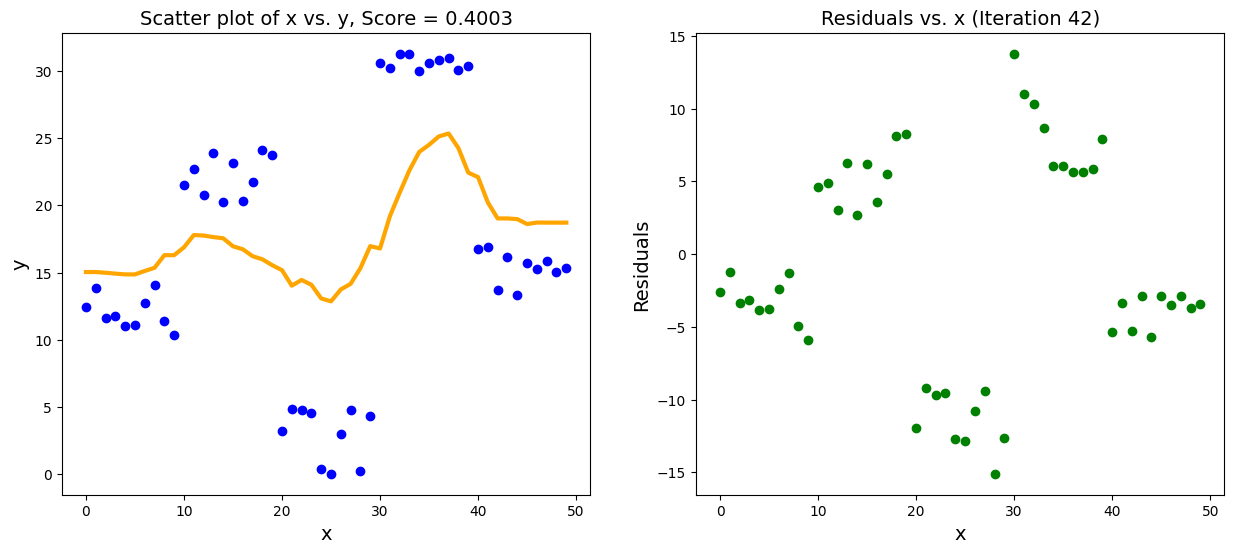

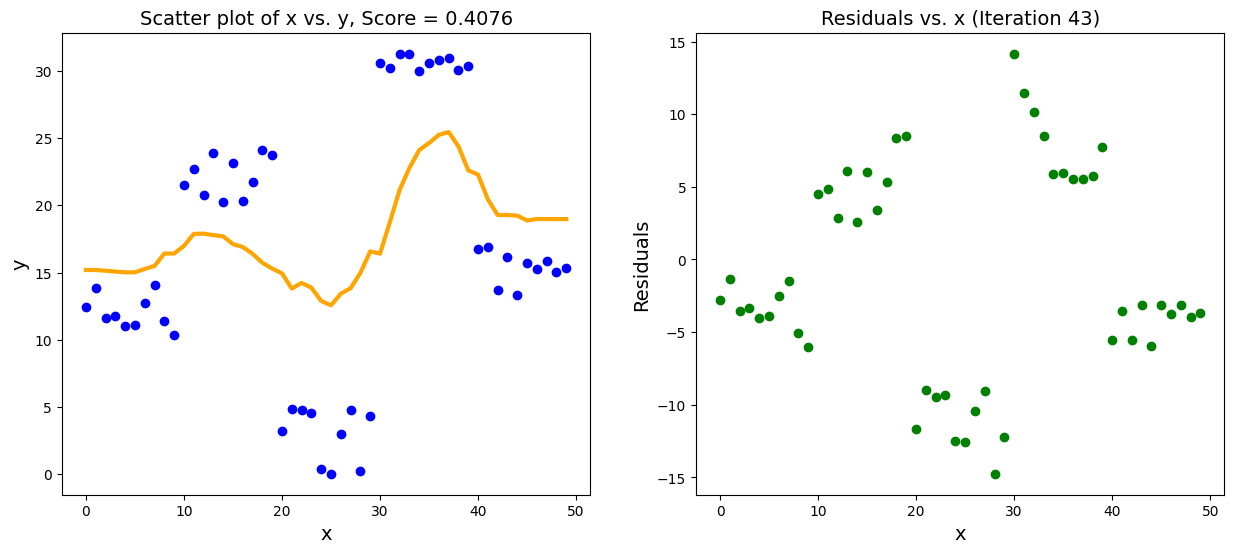

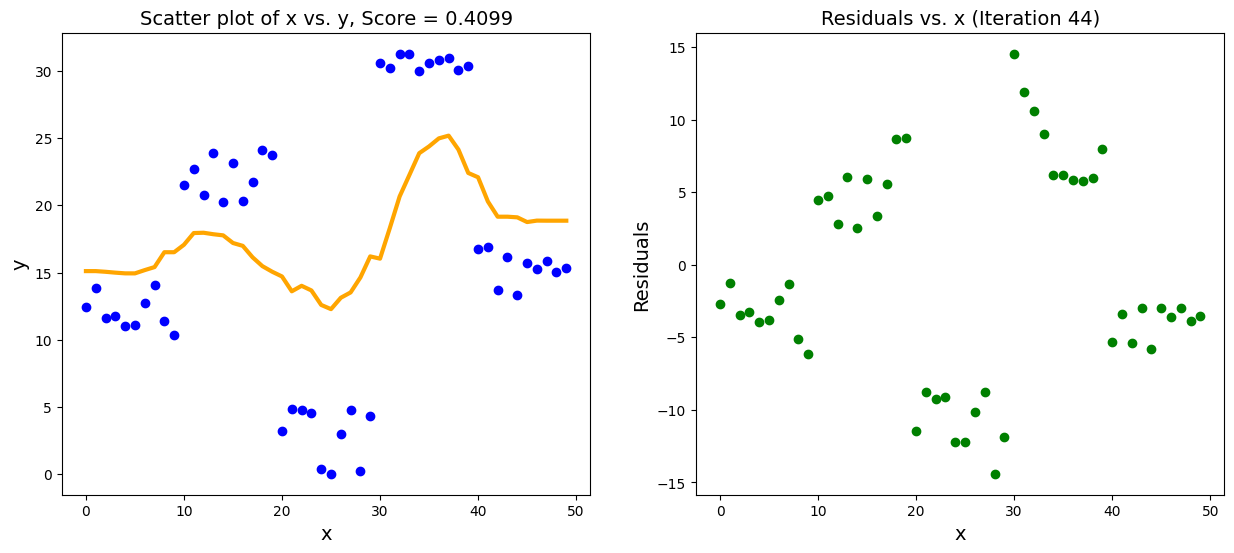

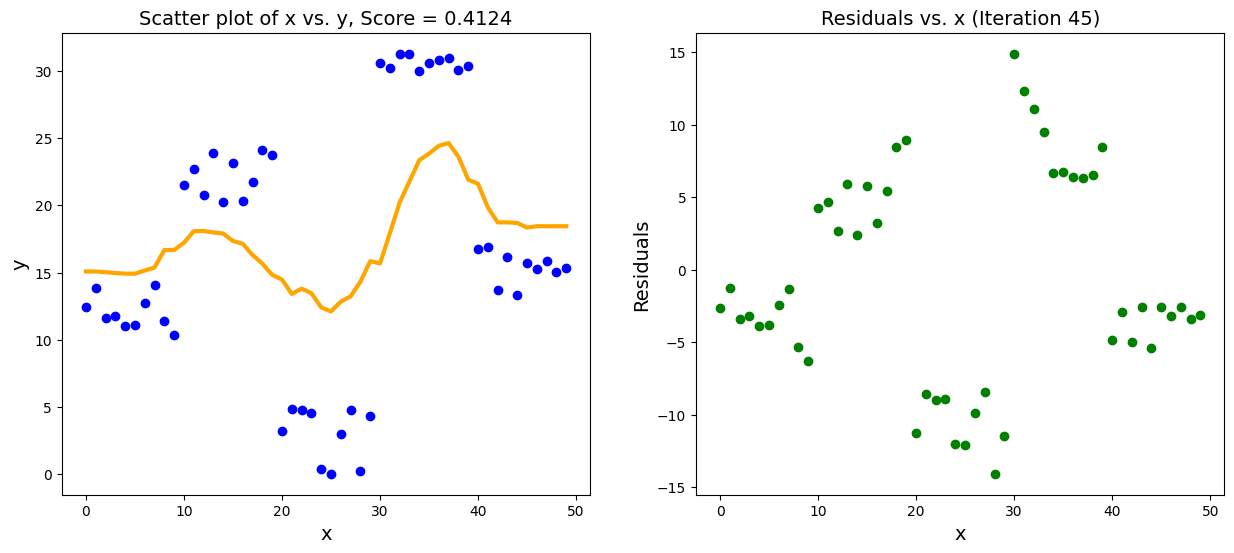

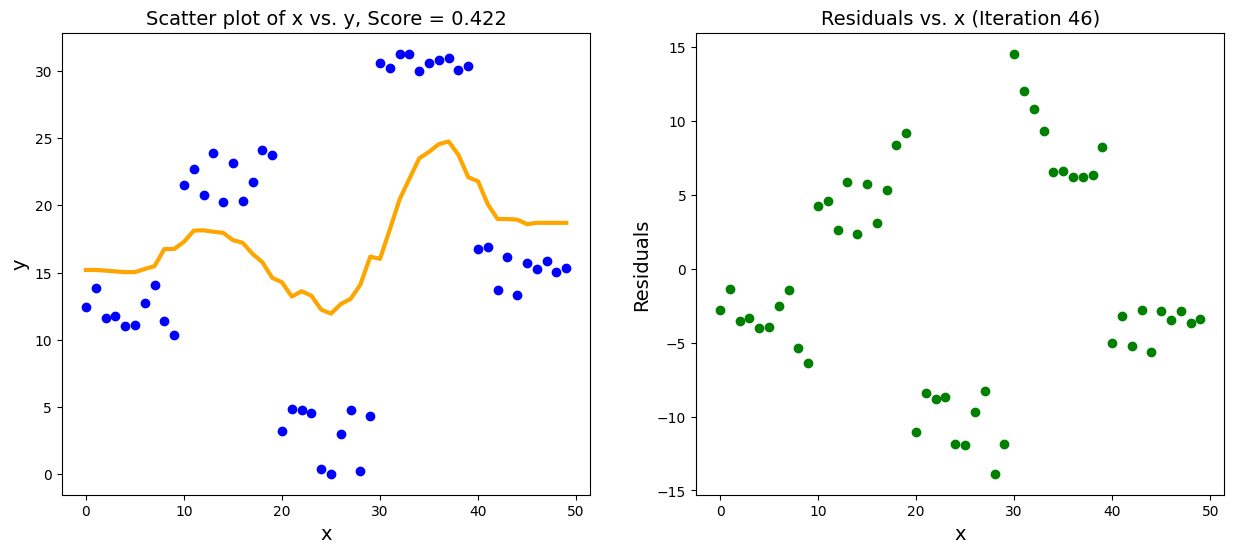

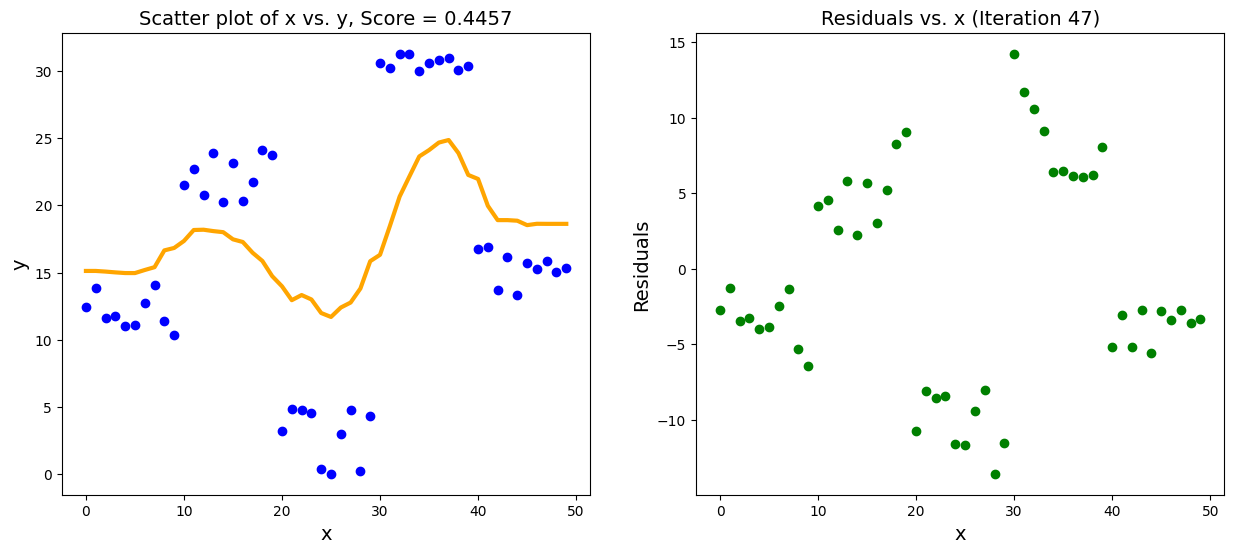

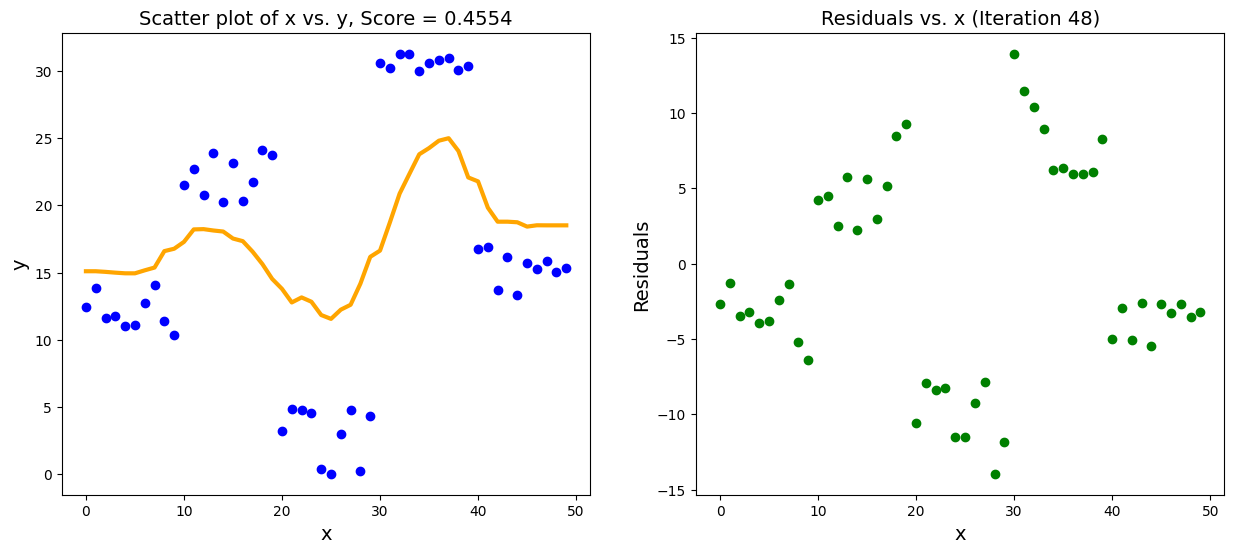

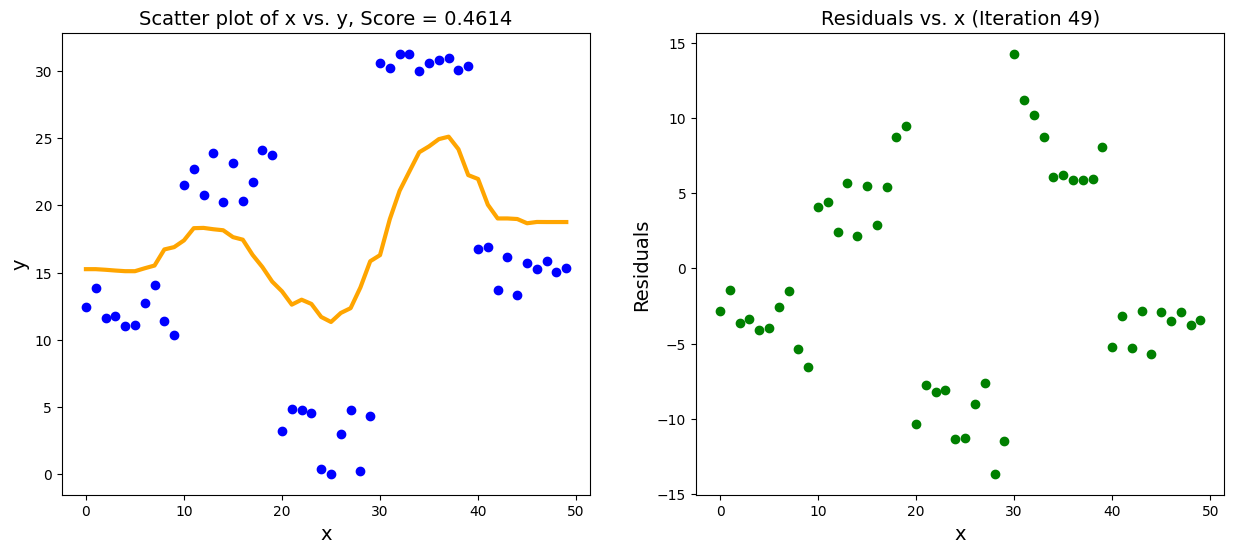

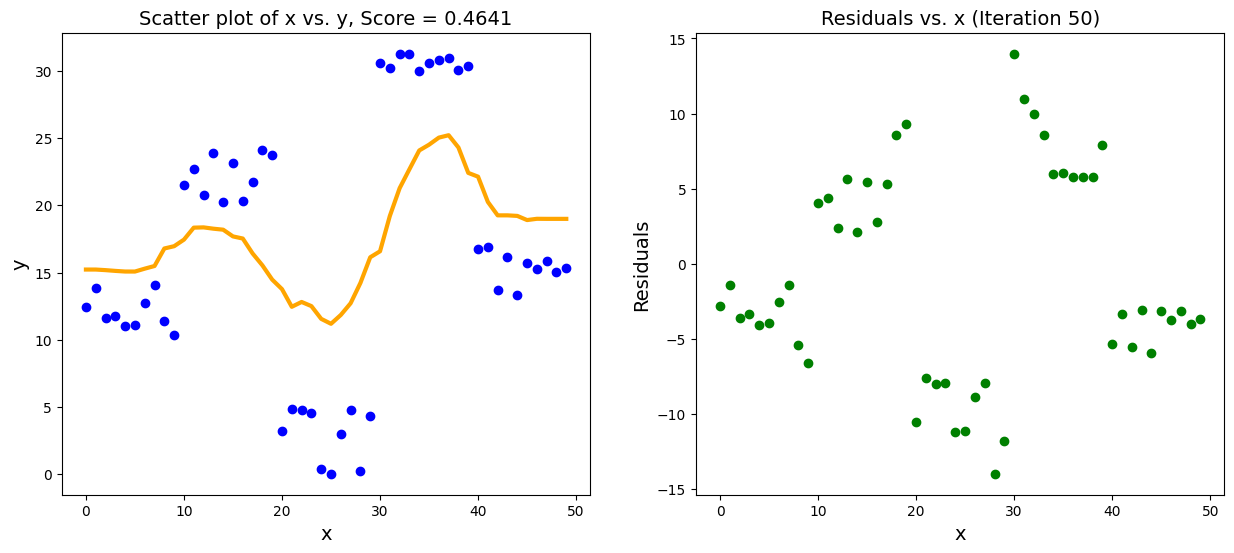

In [8]:
trees = []

for i in range(50):
    # в каждой итерации будем использовать только бутстреп-выборку из 10% объектов с возвратом
    idx = np.random.randint(0, len(x), size=len(x) // 10)
    
    # базовый алгоритм достаточно сложный: дерево с глубиной 5
    tree = DecisionTreeRegressor(max_depth=5, random_state=27)
    tree.fit(x.loc[idx], y[idx])

    trees.append(tree)
    y_pred = 0

    # в качестве результата берём среднее по всем алгоритмам
    for tree in trees:
        y_pred += tree.predict(x).reshape((50, 1))
    y_pred = y_pred / len(trees)

    # остатки - чисто для визуализации
    residuals = y - y_pred
    
    score = r2_score(
        y, y_pred
    )

    plt.figure(figsize=(15, 6))
    plt.subplot(121)
    plt.plot(x, y, "o", color="blue")
    plt.plot(x, y_pred, color="orange", linewidth=3)
    plt.title(f"Scatter plot of x vs. y, Score = {round(score, 4)}", size=14)
    plt.xlabel("x", size=14)
    plt.ylabel("y", size=14)

    plt.subplot(122)
    plt.plot(x, residuals, "o", color="green")
    plt.title(f"Residuals vs. x (Iteration {i+1})", size=14)
    plt.ylabel("Residuals", size=14)
    plt.xlabel("x", size=14)
    plt.show()

Обратите внимание, что после нескольких итераций качество предсказания перестаёт улучшаться, т.е. бэггинг оказался неспособен учесть всю сложность зависимости при небольшом количестве данных

## Загрузка данных

In [12]:
data = pd.read_csv("train.csv")
data.head(n=2)

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.093,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.389,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518


In [13]:
x_train, x_valid = train_test_split(
    data.drop(["ID_code", "target"], axis=1), train_size=0.7, random_state=1
)
y_train, y_valid = train_test_split(
    data["target"], train_size=0.7, random_state=1
)

## 1. Обучение базовой модели XGBoost (sklearn-API)

`XGBoost` поддерживает как свое собственное API, так и `sklearn-API`.

In [14]:
baseline = xgb.XGBClassifier(random_state=27)
baseline.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
y_pred = baseline.predict_proba(x_valid)
score = roc_auc_score(y_valid, y_pred[:, 1])
print(f"score = {round(score, 4)}")

score = 0.8223


## 2. Обучение модели XGBoost с использование оригинального API

In [16]:
xgb_params = {
    "booster": "gbtree",
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": 0.1,
    "reg_lambda": 100,
    "max_depth": 4,
    "nthread": 6,
    "gamma": 10,
    "seed": 27
}

dtrain = xgb.DMatrix(
    data=x_train, label=y_train
)
dvalid = xgb.DMatrix(
    data=x_valid, label=y_valid
)

In [17]:
evals_result = {}

model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=1000,
    maximize=True,
    early_stopping_rounds=50, #критерий ранней остановки (число итераций, в течение которых мы готовы ждать роста метрики качества. т.е. если в теччении 50-и метрик качесто не растетя. то мы прекращаем обучение
    evals_result=evals_result,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    verbose_eval=25, #каждые 25 итераций будем получать сообщение о текущем качестве
    
)

[0]	train-auc:0.63852	valid-auc:0.60328
[25]	train-auc:0.80171	valid-auc:0.73637
[50]	train-auc:0.85056	valid-auc:0.77866
[75]	train-auc:0.87496	valid-auc:0.80127
[100]	train-auc:0.89243	valid-auc:0.81670
[125]	train-auc:0.90232	valid-auc:0.82629
[150]	train-auc:0.91047	valid-auc:0.83405
[175]	train-auc:0.91719	valid-auc:0.84046
[200]	train-auc:0.92335	valid-auc:0.84506
[225]	train-auc:0.92729	valid-auc:0.84898
[250]	train-auc:0.93204	valid-auc:0.85193
[275]	train-auc:0.93534	valid-auc:0.85512
[300]	train-auc:0.93733	valid-auc:0.85767
[325]	train-auc:0.93991	valid-auc:0.85993
[350]	train-auc:0.94032	valid-auc:0.86032
[375]	train-auc:0.94031	valid-auc:0.86042
[400]	train-auc:0.94031	valid-auc:0.86042
[422]	train-auc:0.94031	valid-auc:0.86042


Text(0, 0.5, 'ROC-AUC')

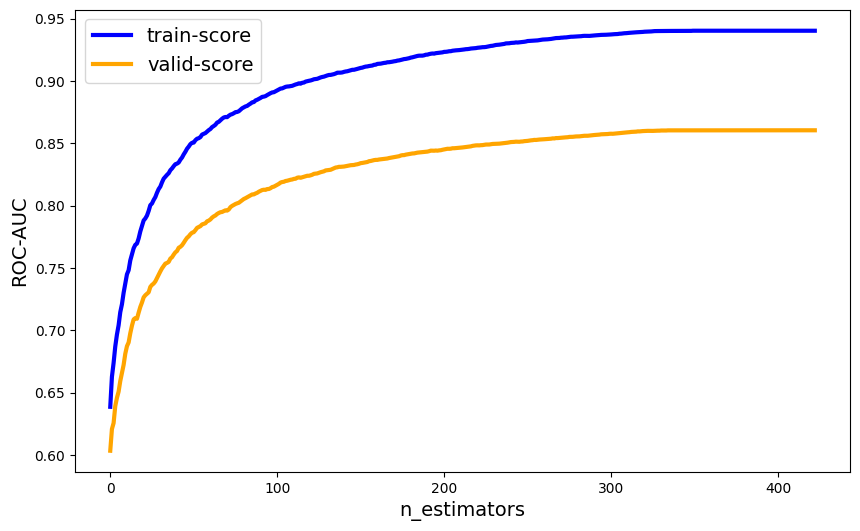

In [18]:
fig = plt.figure(figsize=(10, 6))
plt.plot(evals_result["train"]["auc"], linewidth=3, label="train-score", color="blue")
plt.plot(evals_result["valid"]["auc"], linewidth=3, label="valid-score", color="orange")
plt.legend(loc="best", fontsize=14)
plt.xlabel("n_estimators", size=14)
plt.ylabel("ROC-AUC", size=14)

In [19]:
cv_score = xgb.cv(
    dtrain=dtrain,
    params=xgb_params,
    num_boost_round=1000,
    early_stopping_rounds=50,
    verbose_eval=25,
    maximize=True,
    nfold=3,
)

[0]	train-auc:0.63505+0.00217	test-auc:0.61520+0.00183
[25]	train-auc:0.80689+0.00632	test-auc:0.74768+0.00674
[50]	train-auc:0.85605+0.00585	test-auc:0.78522+0.00507
[75]	train-auc:0.88120+0.00486	test-auc:0.80543+0.00596
[100]	train-auc:0.89692+0.00414	test-auc:0.82005+0.00739
[125]	train-auc:0.90817+0.00418	test-auc:0.83005+0.00684
[150]	train-auc:0.91695+0.00394	test-auc:0.83662+0.00668
[175]	train-auc:0.92404+0.00351	test-auc:0.84234+0.00780
[200]	train-auc:0.92984+0.00313	test-auc:0.84705+0.00781
[225]	train-auc:0.93383+0.00350	test-auc:0.85083+0.00784
[250]	train-auc:0.93763+0.00356	test-auc:0.85371+0.00838
[275]	train-auc:0.93846+0.00344	test-auc:0.85473+0.00813
[300]	train-auc:0.93869+0.00341	test-auc:0.85516+0.00824
[325]	train-auc:0.93869+0.00341	test-auc:0.85519+0.00827
[350]	train-auc:0.93864+0.00347	test-auc:0.85517+0.00825
[368]	train-auc:0.93864+0.00347	test-auc:0.85517+0.00825


Text(0, 0.5, 'ROC-AUC')

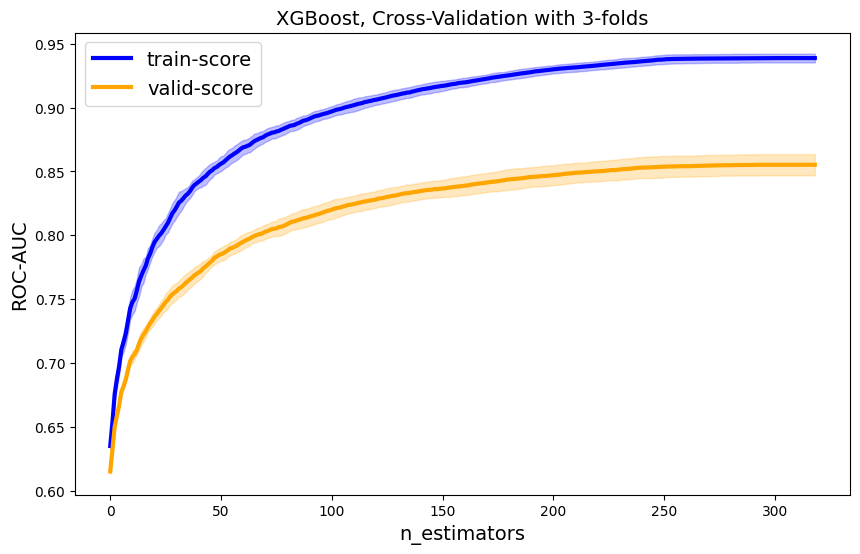

In [20]:
fig = plt.figure(figsize=(10, 6))
plt.title("XGBoost, Cross-Validation with 3-folds", size=14)
plt.plot(
    cv_score["train-auc-mean"],
    label="train-score",
    linewidth=3,
    color="blue"
)
plt.fill_between(
    x=range(cv_score.shape[0]),
    y1=cv_score["train-auc-mean"]-cv_score["train-auc-std"],
    y2=cv_score["train-auc-mean"]+cv_score["train-auc-std"],
    color="blue", alpha=0.25
)
plt.plot(
    cv_score["test-auc-mean"],
    label="valid-score",
    color="orange",
    linewidth=3
)
plt.fill_between(
    x=range(cv_score.shape[0]),
    y1=cv_score["test-auc-mean"]-cv_score["test-auc-std"],
    y2=cv_score["test-auc-mean"]+cv_score["test-auc-std"],
    color="orange", alpha=0.25
)
plt.legend(loc="best", fontsize=14)
plt.xlabel("n_estimators", size=14)
plt.ylabel("ROC-AUC", size=14)

## 3. Интерпретация работы модели XGBoost

In [21]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_valid)

## 3.1. Интерпретация поведения модели на одном объекте

In [22]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0,:], x_valid.iloc[0,:],
    link="logit"
)

#итог: вероятность соверешения покупки клиентом
#красные признаки увеличивают вероятность совершения покупки, синии - уменьшают

## 3.2. Пути принятия решений моделью на совокупности объектов

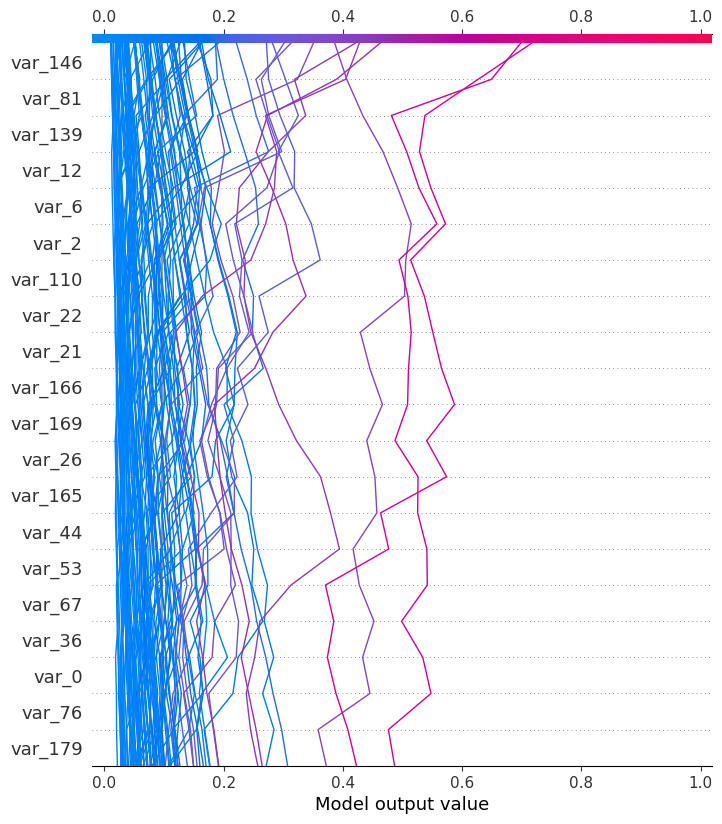

In [23]:
idx = np.random.randint(
    0, x_valid.shape[0], 100
)

shap.decision_plot(
    explainer.expected_value,
    shap_values[idx, :],
    x_valid.iloc[idx,:],
    link="logit")

## 3.3. Важность признаков для модели

C:\Users\Mariy\AppData\Local\Temp\ipykernel_7872\2618316753.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


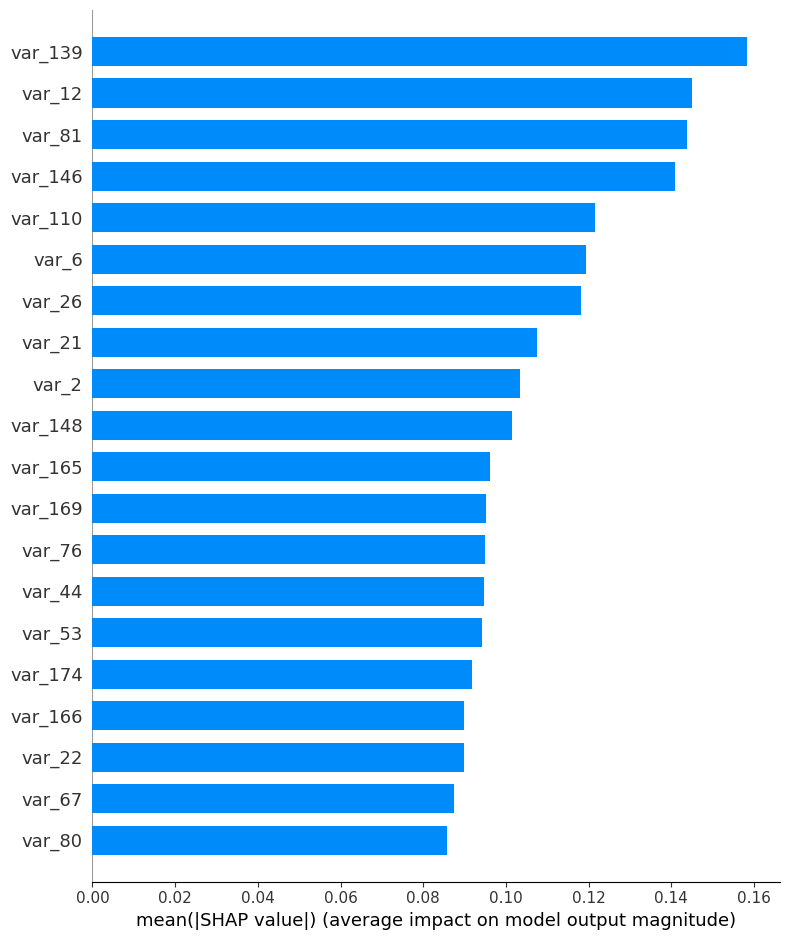

In [24]:
shap.summary_plot(
    shap_values, x_valid, plot_type="bar", max_display=20
)

## 3.4. Взаимодействие признаков между собой

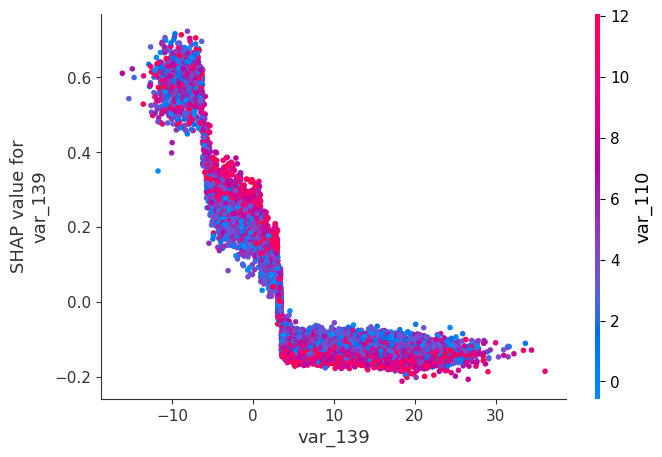

In [25]:
shap.dependence_plot("var_139", shap_values, x_valid)

## 3.5. Суммарный эффект для всех признаков

C:\Users\Mariy\AppData\Local\Temp\ipykernel_7872\2400446665.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_valid)


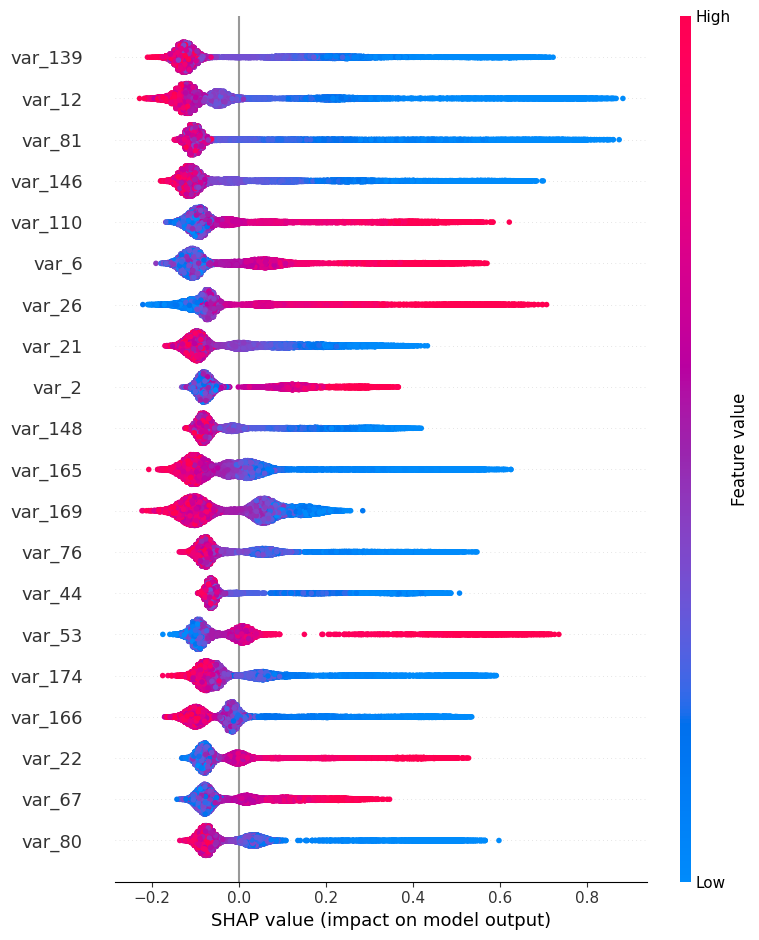

In [27]:
shap.summary_plot(shap_values, x_valid)
#показывает поведение всех признаков модели
#горизонт.ось - вклад признака в прогнозное значение модели
#красный - большое значение, синий - маленькое 
#каждая полоска отвечает за распределение признака

## 4. Обучение базовой модели CatBoost (sklearn-API)

`CatBoost` поддерживает как свое собственное `API`, так и `sklearn-API`.

In [28]:
model = cb.CatBoostClassifier(random_state=27)
model.fit(x_train, y_train)

Learning rate set to 0.050823
0:	learn: 0.6493754	total: 366ms	remaining: 6m 5s
1:	learn: 0.6110141	total: 498ms	remaining: 4m 8s
2:	learn: 0.5771442	total: 568ms	remaining: 3m 8s
3:	learn: 0.5469271	total: 652ms	remaining: 2m 42s
4:	learn: 0.5202961	total: 749ms	remaining: 2m 29s
5:	learn: 0.4967743	total: 825ms	remaining: 2m 16s
6:	learn: 0.4755535	total: 908ms	remaining: 2m 8s
7:	learn: 0.4570217	total: 978ms	remaining: 2m 1s
8:	learn: 0.4408103	total: 1.05s	remaining: 1m 55s
9:	learn: 0.4261178	total: 1.12s	remaining: 1m 50s
10:	learn: 0.4135912	total: 1.19s	remaining: 1m 46s
11:	learn: 0.4027117	total: 1.26s	remaining: 1m 43s
12:	learn: 0.3924793	total: 1.36s	remaining: 1m 43s
13:	learn: 0.3837103	total: 1.44s	remaining: 1m 41s
14:	learn: 0.3762103	total: 1.51s	remaining: 1m 38s
15:	learn: 0.3689805	total: 1.57s	remaining: 1m 36s
16:	learn: 0.3626765	total: 1.65s	remaining: 1m 35s
17:	learn: 0.3565417	total: 1.72s	remaining: 1m 33s
18:	learn: 0.3513020	total: 1.78s	remaining: 1m 3

CatBoostClassifier(random_state=27)

In [29]:
y_pred = model.predict_proba(x_valid)
score = roc_auc_score(y_valid, y_pred[:, 1])
print(f"score = {round(score, 4)}")

score = 0.8747


## 5. Обучение модели CatBoost с использование оригинального API

In [30]:
cb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "task_type": "CPU",
    "verbose": 50,
    "max_depth": 6,
    "l2_leaf_reg": 10,
    "early_stopping_rounds": 50,
    "thread_count": 6,
    "random_seed": 42
}

cb_train = cb.Pool(
    data=x_train, label=y_train, cat_features=None
)
cb_valid = cb.Pool(
    data=x_valid, label=y_valid, cat_features=None
)

In [31]:
model = cb.train(
    params=cb_params,
    dtrain=cb_train,
    eval_set=[cb_train, cb_valid],
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.5743413	test1: 0.5575319	best: 0.5575319 (0)	total: 97ms	remaining: 8m 4s
50:	test: 0.8342644	test1: 0.7539641	best: 0.7555973 (49)	total: 4.69s	remaining: 7m 35s
100:	test: 0.8286367	test1: 0.7679550	best: 0.7692494 (84)	total: 8.96s	remaining: 7m 14s
150:	test: 0.8219675	test1: 0.7712560	best: 0.7725185 (118)	total: 13.1s	remaining: 7m 1s
200:	test: 0.8246509	test1: 0.7784949	best: 0.7784949 (200)	total: 17.5s	remaining: 6m 58s
250:	test: 0.8305959	test1: 0.7845840	best: 0.7845840 (250)	total: 21.6s	remaining: 6m 48s
300:	test: 0.8341208	test1: 0.7895367	best: 0.7896780 (299)	total: 25.7s	remaining: 6m 40s
350:	test: 0.8393831	test1: 0.7950170	best: 0.7950270 (349)	total: 29.9s	remaining: 6m 36s
400:	test: 0.8454068	test1: 0.8006840	best: 0.8006923 (399)	total: 34.2s	remaining: 6m 32s
450:	test: 0.8500478	test1: 0.8055809	best: 0.8055809 (450)	total: 38.4s	remaining: 6m 27s
500:	test: 0.8553930	test1: 0.8109984	best: 0.8109984 (500)	total: 42.4s	remaining: 6m 21s
550:	test

KeyboardInterrupt: 

In [32]:
catboost_cv = cb.cv(
    pool=cb_train,
    params=cb_params,
    plot=True,
    nfold=3,
    seed=27
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/3]
0:	test: 0.5486083	best: 0.5486083 (0)	total: 150ms	remaining: 12m 30s
50:	test: 0.7689651	best: 0.7689651 (50)	total: 4.24s	remaining: 6m 51s


KeyboardInterrupt: 

**ДЗ**

Разбейте датасет в соотношении 70/30 на обучающую и тестовую выборку.

In [43]:
df=pd.read_csv("data_boost.csv")
df.head(2)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
features = ['TransactionAmt', 'card1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1']

x_train, x_test = train_test_split(
    df[features], train_size=0.7, shuffle=True, random_state=1,
)
y_train, y_test = train_test_split(
    df["isFraud"], train_size=0.7, shuffle=True, random_state=1,
)

Обучите алгоритм Catboost в варианте «из коробки» (без доп. настройки параметров) на трейновых данных и посчитайте, какое значение ROC AUC алгоритм выдаёт на тестовой части

In [49]:
model = cb.CatBoostClassifier(random_state=27)
model.fit(x_test, y_test)

Learning rate set to 0.044021
0:	learn: 0.6154721	total: 23ms	remaining: 23s
1:	learn: 0.5437700	total: 57ms	remaining: 28.4s
2:	learn: 0.4868725	total: 81.1ms	remaining: 26.9s
3:	learn: 0.4358177	total: 104ms	remaining: 25.9s
4:	learn: 0.3927279	total: 122ms	remaining: 24.3s
5:	learn: 0.3554256	total: 141ms	remaining: 23.4s
6:	learn: 0.3244522	total: 160ms	remaining: 22.7s
7:	learn: 0.2970770	total: 179ms	remaining: 22.1s
8:	learn: 0.2724780	total: 198ms	remaining: 21.8s
9:	learn: 0.2526029	total: 211ms	remaining: 20.9s
10:	learn: 0.2337200	total: 229ms	remaining: 20.6s
11:	learn: 0.2177081	total: 247ms	remaining: 20.4s
12:	learn: 0.2023973	total: 268ms	remaining: 20.4s
13:	learn: 0.1898324	total: 286ms	remaining: 20.1s
14:	learn: 0.1791944	total: 303ms	remaining: 19.9s
15:	learn: 0.1692471	total: 321ms	remaining: 19.7s
16:	learn: 0.1600312	total: 338ms	remaining: 19.5s
17:	learn: 0.1527322	total: 356ms	remaining: 19.4s
18:	learn: 0.1464606	total: 375ms	remaining: 19.3s
19:	learn: 0.1

CatBoostClassifier(random_state=27)

Аналогичным образом обучите на трейновой части XGBoost «из коробки» и посчитайте значение ROC AUC. Какой алгоритм показал себя лучше в базовом варианте?

In [50]:
baseline = xgb.XGBClassifier(random_state=27)
baseline.fit(x_train, y_train)

y_pred = baseline.predict_proba(x_test)
score = roc_auc_score(y_test, y_pred[:, 1])
print(f"score = {round(score, 4)}")

score = 0.9128


Алгоритм XGBoost показал лучший результат, его метрика значительно выше, чем у CatBoost.

При помощи оригинального API попробуйте настроить XGBoost таким образом, чтобы он показал лучшее значение ROC AUC на тестовой части. Измените learning rate, вес регуляризации, количество эпох, параметры дерева… Удалось ли добиться результата лучше, чем Catboost?

In [51]:
xgb_params = {
    "booster": "gbtree",
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": 0.1,
    "reg_lambda": 100,
    "max_depth": 5,
    "nthread": 6,
    "gamma": 10,
    "seed": 27
}

dtrain = xgb.DMatrix(
    data=x_train, label=y_train
)
dtest = xgb.DMatrix(
    data=x_test, label=y_test
)

evals_result = {}

model = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=1000,
    maximize=True,
    early_stopping_rounds=50, #критерий ранней остановки (число итераций, в течение которых мы готовы ждать роста метрики качества. т.е. если в теччении 50-и метрик качесто не растетя. то мы прекращаем обучение
    evals_result=evals_result,
    evals=[(dtrain, "train"), (dtest, "test")],
    verbose_eval=25, #каждые 25 итераций будем получать сообщение о текущем качестве
    
)

[0]	train-auc:0.78709	test-auc:0.78219
[25]	train-auc:0.86512	test-auc:0.85722
[50]	train-auc:0.87678	test-auc:0.86379
[75]	train-auc:0.87726	test-auc:0.86405
[100]	train-auc:0.87726	test-auc:0.86405
[101]	train-auc:0.87726	test-auc:0.86405


 Значение метрики у CatBoost: 0.6154721, у XGBoost - 86405. Лучшего результата добится удалось 